# Overview:
### 1) Exploratory Data Analysis (EDA) 
### 2) Outlier Screening and Handling Procedures
### 3) Variable Selection Procedures
### 4) Goodness of Fit Testing and Model Assumptions
### 5) Model Training and Evaluation 
### 6) Statistical Analysis and Hypothesis Testing
### 7) Cross-validation and Model Selection Procedures 

## 1) Exploratory Data Analysis:

#### Import libraries:

In [1]:
library(readr)
library(dplyr)
library(tidyr)
library(tidyverse)
library(janitor)   
library(corrplot)
library(ggplot2)
library(hexbin)
library(car)
library(caret)
set.seed(111) 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ purrr     1.0.4
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


corrplot 0.95 loaded

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:purrr’:

    some


The following object is masked from ‘package:dplyr’:

    recode


Loa

#### Load Data:

In [2]:
df <- read_csv( "~/Documents/ISYE_6414_Final_Project-Adrian/1_data_loading_cleaning/merged_data/merged_state.csv")
names(df)

Rows: 229188 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): OPEID6.x, INSTNM.x, CIPCODE, CIPDESC, CREDDESC, OPEID, OPEID6.y, I...
dbl (40): UNITID, CREDLEV, CONTROL, REGION, ADM_RATE, ADM_RATE_ALL, SAT_AVG,...
lgl  (1): LOCALE

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "UNITID"              "OPEID6.x"            "INSTNM.x"           
 [4] "CIPCODE"             "CIPDESC"             "CREDLEV"            
 [7] "CREDDESC"            "OPEID"               "OPEID6.y"           
[10] "INSTNM.y"            "CITY"                "STABBR"             
[13] "ZIP"                 "CONTROL"             "REGION"             
[16] "LOCALE"              "ADM_RATE"            "ADM_RATE_ALL"       
[19] "SAT_AVG"             "ACTCMMID"            "TUITFTE"            
[22] "INEXPFTE"            "TUITIONFEE_IN"       "TUITIONFEE_OUT"     
[25] "ROOMBOARD_OFF"       "OTHEREXPENSE_OFF"    "BOOKSUPPLY"         
[28] "UGDS"                "UGDS_MEN"            "UGDS_WOMEN"         
[31] "UGDS_WHITE"          "UGDS_BLACK"          "UGDS_HISP"          
[34] "UGDS_ASIAN"          "UGDS_AIAN"           "UGDS_NHPI"          
[37] "UGDS_2MOR"           "UGDS_NRA"            "UGDS_UNKN"          
[40] "avg_hourly_earnings" "avg_weekly_earnings" "avg_weekly_hours"   
[43] "Debt_24"             "Borrowers_24"        "Debt_25-34"         
[46] "Borrowers_25-34"     "Debt_35-49"          "Borrowers_35-49"    
[49] "Debt_50-61"          "Borrowers_50-61"     "Debt_62_Plus"       
[52] "Borrowers_62_Plus"

#### Create Response Variable:

In [3]:
# aggregate debt and income
df <- df %>%
mutate(Total_Debt = Borrowers_24 + `Debt_25-34` + `Debt_35-49` + `Debt_50-61` + Debt_62_Plus)%>%
mutate(Annual_Income = avg_weekly_earnings * 52)%>% # multiply by weeks in year
mutate(Debt_to_Income_Ratio = Total_Debt / Annual_Income ) # create debt to income ratio
df

UNITID,OPEID6.x,INSTNM.x,CIPCODE,CIPDESC,CREDLEV,CREDDESC,OPEID,OPEID6.y,INSTNM.y,⋯,Borrowers_25-34,Debt_35-49,Borrowers_35-49,Debt_50-61,Borrowers_50-61,Debt_62_Plus,Borrowers_62_Plus,Total_Debt,Annual_Income,Debt_to_Income_Ratio
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100654,001002,Alabama A & M University,0100,"Agriculture, General.",3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0101,Agricultural Business and Management.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0109,Animal Sciences.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0110,Food Science and Technology.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0110,Food Science and Technology.,5,Master's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0110,Food Science and Technology.,6,Doctoral Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0111,Plant Sciences.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0199,"Agriculture, Agriculture Operations, and Related Sciences, Other.",3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0199,"Agriculture, Agriculture Operations, and Related Sciences, Other.",5,Master's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426


#### Check for Missing Data:


column_name,percentage_missing
<chr>,<dbl>
LOCALE,1.0000000
ACTCMMID,0.5424586
SAT_AVG,0.5389549
ADM_RATE,0.4232421
ADM_RATE_ALL,0.4120373
ROOMBOARD_OFF,0.1257439
OTHEREXPENSE_OFF,0.1257439
BOOKSUPPLY,0.1139021
TUITIONFEE_IN,0.1081950


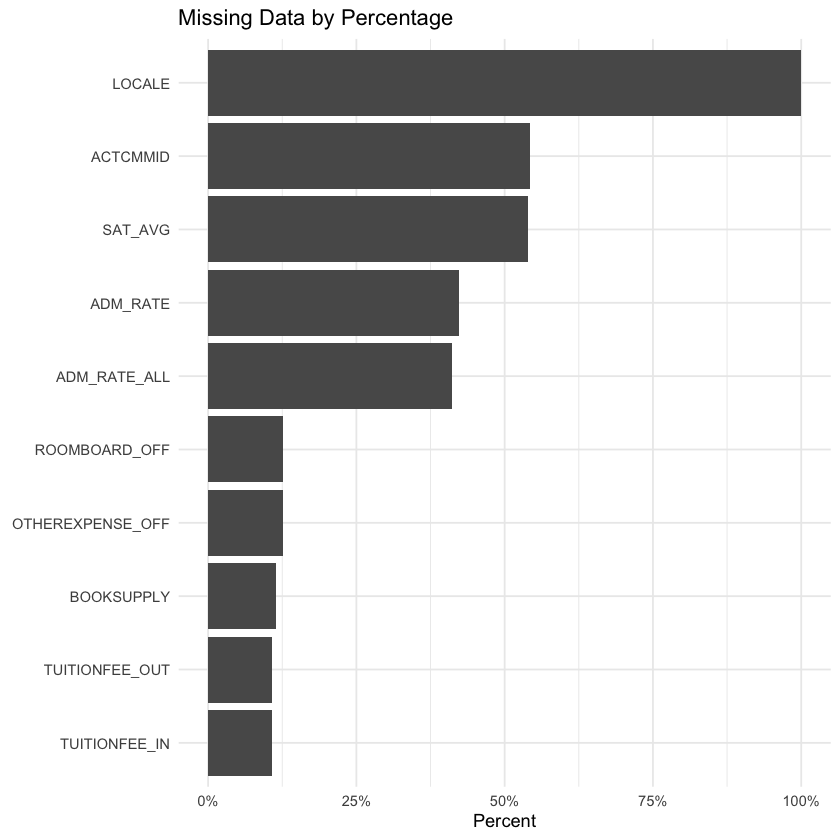

In [4]:
missing_data <- df  %>% 
summarise(across(everything(), ~ mean(is.na(.)))) %>%
pivot_longer(everything(), names_to = "column_name", values_to = "percentage_missing") %>%
arrange(desc(percentage_missing))
head(missing_data, 10)

# focus on columns missing more that 10% of data
missing_data %>% 
filter(percentage_missing > 0.1) %>%
ggplot(aes(x = percentage_missing, y = fct_reorder(column_name, percentage_missing))) +
geom_col() +
scale_x_continuous(labels = scales::percent) +
labs(title = "Missing Data by Percentage",
     x = "Percent", y = NULL) + theme_minimal()


The columns LOCALE, ACTCMMID, SAT_AVG, ADM_RATE, and ADM_RATE_ALL have high rates of missing data. Columns LOCALE, ACTCMMID, and SAT_AVG all have more than 50% of values missing. ADM_RATE and ADM_RATE_ALL are missing more than 30% of their values. Removing data with high rates is a precaution to minimize the risk of bias. 

#### Drop Columns with High Percentage of Missing Values:

In [5]:
df  <- df [, !names(df ) %in% c("LOCALE", "ACTCMMID", "SAT_AVG", "ADM_RATE", "ADM_RATE_ALL")]
df

UNITID,OPEID6.x,INSTNM.x,CIPCODE,CIPDESC,CREDLEV,CREDDESC,OPEID,OPEID6.y,INSTNM.y,⋯,Borrowers_25-34,Debt_35-49,Borrowers_35-49,Debt_50-61,Borrowers_50-61,Debt_62_Plus,Borrowers_62_Plus,Total_Debt,Annual_Income,Debt_to_Income_Ratio
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100654,001002,Alabama A & M University,0100,"Agriculture, General.",3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0101,Agricultural Business and Management.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0109,Animal Sciences.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0110,Food Science and Technology.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0110,Food Science and Technology.,5,Master's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0110,Food Science and Technology.,6,Doctoral Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0111,Plant Sciences.,3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0199,"Agriculture, Agriculture Operations, and Related Sciences, Other.",3,Bachelor's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,001002,Alabama A & M University,0199,"Agriculture, Agriculture Operations, and Related Sciences, Other.",5,Master's Degree,00100200,001002,Alabama A & M University,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426


#### Check for Missing Data in Reduced df :

column_name,percentage_missing
<chr>,<dbl>
ROOMBOARD_OFF,0.12574393
OTHEREXPENSE_OFF,0.12574393
BOOKSUPPLY,0.11390212
TUITIONFEE_IN,0.10819502
TUITIONFEE_OUT,0.10819502
avg_hourly_earnings,0.06135574
avg_weekly_earnings,0.06135574
avg_weekly_hours,0.06135574
Debt_24,0.06135574


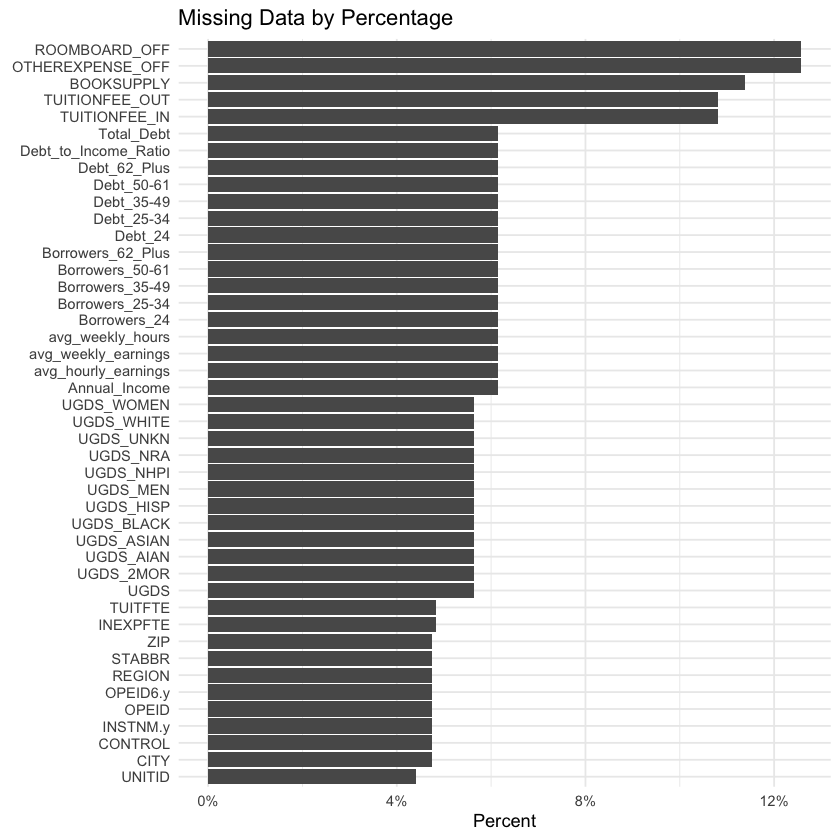

In [6]:
missing_tbl <- df %>%
summarise(across(everything(), ~ mean(is.na(.)))) %>%
pivot_longer(everything(), names_to = "column_name", values_to = "percentage_missing") %>%
arrange(desc(percentage_missing))

head(missing_tbl, 10)

missing_tbl %>%
filter(percentage_missing > 0.01) %>%
ggplot(aes(x = percentage_missing, y = fct_reorder(column_name, percentage_missing))) +
geom_col() +
scale_x_continuous(labels = scales::percent) +
labs(title = "Missing Data by Percentage",
     x = "Percent", y = NULL) + theme_minimal()

Now that LOCALE, ACTCMMID, SAT_AVG, ADM_RATE, and ADM_RATE_ALL have been removed from the df, the columns with the highest rates of missing values are ROOMBOARD_OFF, OTHEREXPENSE_OFF, BOOKSUPPLY, TUITIONFEE_IN, and TUITIONFEE_OUT, each with about 10% missing values. The other columns are missing 4% to 6% of values. This low proportion of missing data does not pose a significant risk of bias.  

#### Inspect Data:

In [7]:
names(df)
glimpse(df)

[1] "UNITID"               "OPEID6.x"             "INSTNM.x"            
 [4] "CIPCODE"              "CIPDESC"              "CREDLEV"             
 [7] "CREDDESC"             "OPEID"                "OPEID6.y"            
[10] "INSTNM.y"             "CITY"                 "STABBR"              
[13] "ZIP"                  "CONTROL"              "REGION"              
[16] "TUITFTE"              "INEXPFTE"             "TUITIONFEE_IN"       
[19] "TUITIONFEE_OUT"       "ROOMBOARD_OFF"        "OTHEREXPENSE_OFF"    
[22] "BOOKSUPPLY"           "UGDS"                 "UGDS_MEN"            
[25] "UGDS_WOMEN"           "UGDS_WHITE"           "UGDS_BLACK"          
[28] "UGDS_HISP"            "UGDS_ASIAN"           "UGDS_AIAN"           
[31] "UGDS_NHPI"            "UGDS_2MOR"            "UGDS_NRA"            
[34] "UGDS_UNKN"            "avg_hourly_earnings"  "avg_weekly_earnings" 
[37] "avg_weekly_hours"     "Debt_24"              "Borrowers_24"        
[40] "Debt_25-34"           "Borrowers_25-34"      "Debt_35-49"          
[43] "Borrowers_35-49"      "Debt_50-61"           "Borrowers_50-61"     
[46] "Debt_62_Plus"         "Borrowers_62_Plus"    "Total_Debt"          
[49] "Annual_Income"        "Debt_to_Income_Ratio"

Rows: 229,188
Columns: 50
$ UNITID               <dbl> 100654, 100654, 100654, 100654, 100654, 100654, 1…
$ OPEID6.x             <chr> "001002", "001002", "001002", "001002", "001002",…
$ INSTNM.x             <chr> "Alabama A & M University", "Alabama A & M Univer…
$ CIPCODE              <chr> "0100", "0101", "0109", "0110", "0110", "0110", "…
$ CIPDESC              <chr> "Agriculture, General.", "Agricultural Business a…
$ CREDLEV              <dbl> 3, 3, 3, 3, 5, 6, 3, 3, 5, 6, 3, 3, 5, 3, 5, 3, 3…
$ CREDDESC             <chr> "Bachelor's Degree", "Bachelor's Degree", "Bachel…
$ OPEID                <chr> "00100200", "00100200", "00100200", "00100200", "…
$ OPEID6.y             <chr> "001002", "001002", "001002", "001002", "001002",…
$ INSTNM.y             <chr> "Alabama A & M University", "Alabama A & M Univer…
$ CITY                 <chr> "Normal", "Normal", "Normal", "Normal", "Normal",…
$ STABBR               <chr> "AL", "AL", "AL", "AL", "AL", "AL", "AL", "AL", "…
$ ZIP         

#### Focusing on Numeric Columns:

In [8]:
eda_df <- df %>%
select(where(is.numeric))
head(eda_df)
summary(eda_df)

UNITID,CREDLEV,CONTROL,REGION,TUITFTE,INEXPFTE,TUITIONFEE_IN,TUITIONFEE_OUT,ROOMBOARD_OFF,OTHEREXPENSE_OFF,⋯,Borrowers_25-34,Debt_35-49,Borrowers_35-49,Debt_50-61,Borrowers_50-61,Debt_62_Plus,Borrowers_62_Plus,Total_Debt,Annual_Income,Debt_to_Income_Ratio
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100654,3,1,5,8101,4836,10024,18634,9240,3090,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,3,1,5,8101,4836,10024,18634,9240,3090,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,3,1,5,8101,4836,10024,18634,9240,3090,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,3,1,5,8101,4836,10024,18634,9240,3090,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,5,1,5,8101,4836,10024,18634,9240,3090,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426
100654,6,1,5,8101,4836,10024,18634,9240,3090,⋯,204.6,9.5e+09,192.6,3.76e+09,83.3,1.05e+09,26.3,2.141e+10,58112.08,368426


     UNITID          CREDLEV        CONTROL          REGION     
 Min.   :100654   Min.   :1.00   Min.   :1.000   Min.   :0.000  
 1st Qu.:149231   1st Qu.:2.00   1st Qu.:1.000   1st Qu.:3.000  
 Median :187532   Median :3.00   Median :1.000   Median :5.000  
 Mean   :202262   Mean   :3.27   Mean   :1.443   Mean   :4.496  
 3rd Qu.:220978   3rd Qu.:5.00   3rd Qu.:2.000   3rd Qu.:6.000  
 Max.   :497338   Max.   :8.00   Max.   :3.000   Max.   :9.000  
 NA's   :10109                   NA's   :10871   NA's   :10871  
    TUITFTE          INEXPFTE      TUITIONFEE_IN   TUITIONFEE_OUT 
 Min.   :     0   Min.   :     0   Min.   :  480   Min.   :  480  
 1st Qu.:  3845   1st Qu.:  5901   1st Qu.: 5206   1st Qu.:10104  
 Median :  9289   Median :  8496   Median :10198   Median :20110  
 Mean   : 11026   Mean   : 11417   Mean   :17147   Mean   :23437  
 3rd Qu.: 15254   3rd Qu.: 12300   3rd Qu.:26874   3rd Qu.:33386  
 Max.   :795335   Max.   :586058   Max.   :61671   Max.   :61671  
 NA's   :11

## 2) Outlier Screening and Handling Procedures:

#### Inspect Debt Related Distributions:

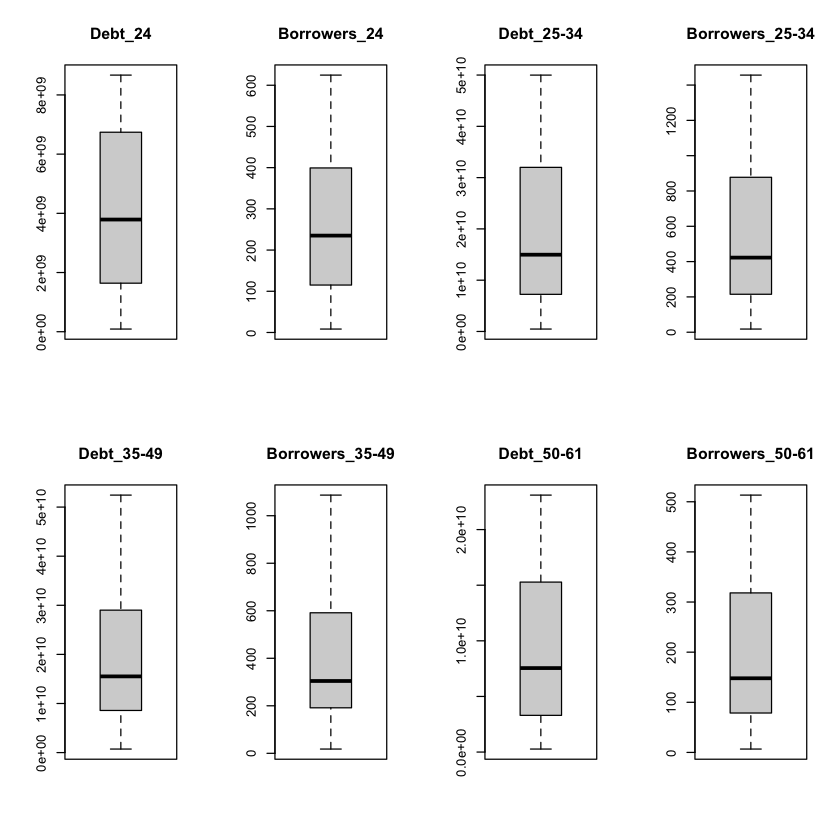

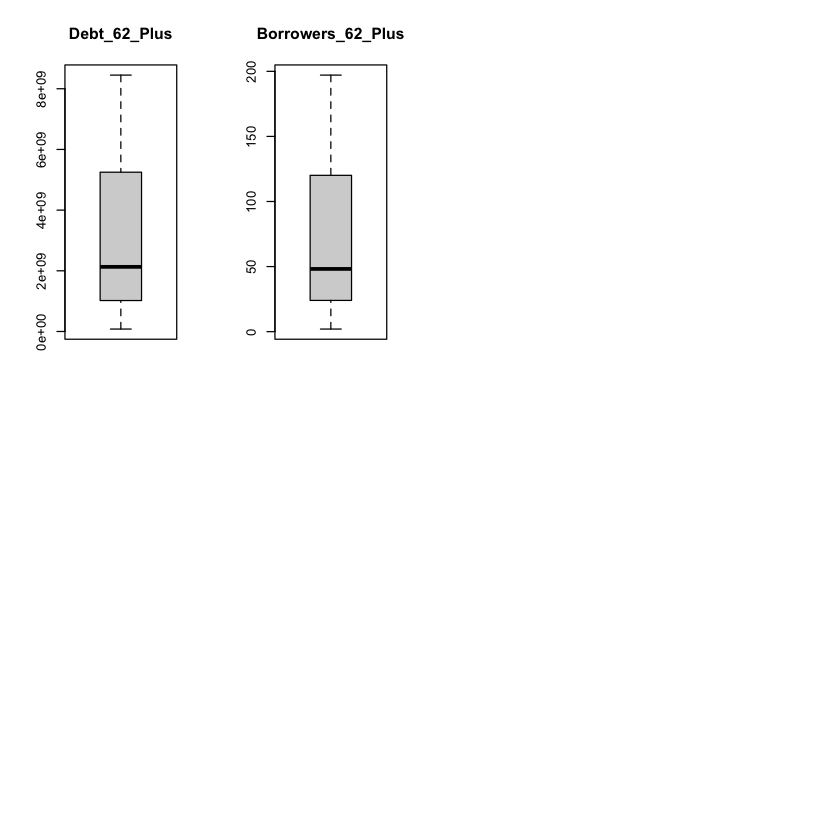

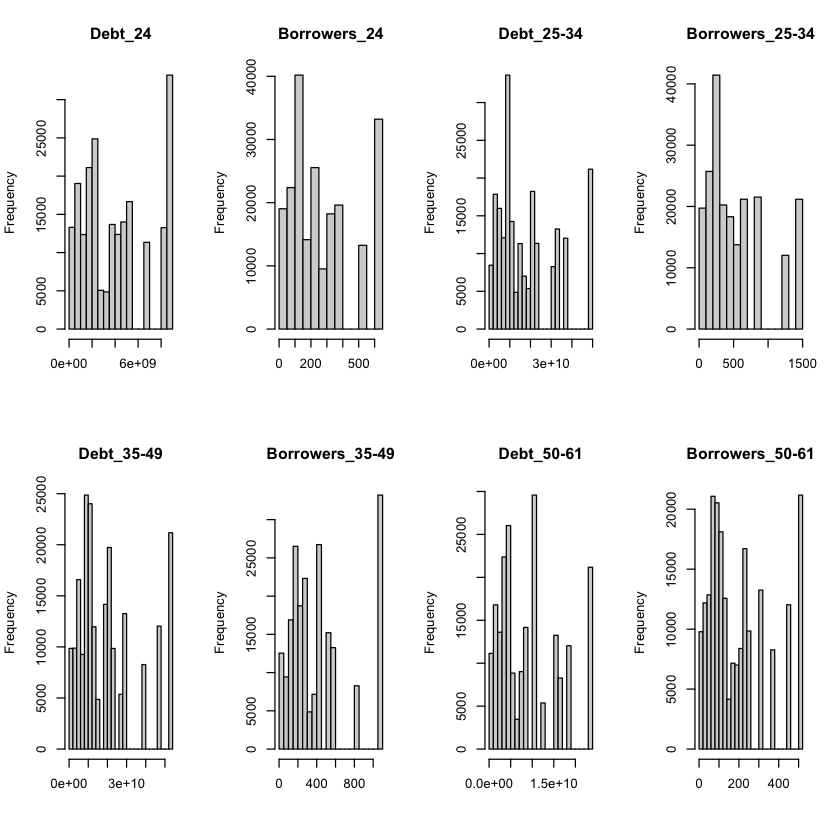

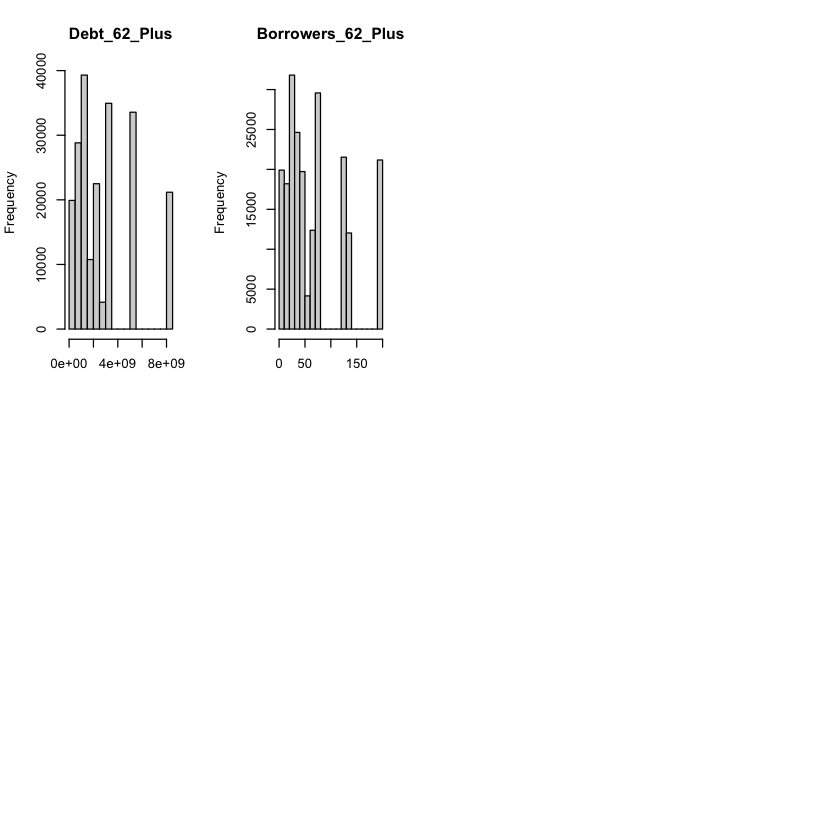

In [9]:

inspect_debt <- eda_df %>% 
select('Debt_24', 'Borrowers_24', 'Debt_25-34',
'Borrowers_25-34','Debt_35-49','Borrowers_35-49','Debt_50-61','Borrowers_50-61','Debt_62_Plus','Borrowers_62_Plus')

# boxplots
par(mfrow = c(2,4))
for(col in names(inspect_debt)) 
    boxplot(inspect_debt [[col]], main = col)

# histogram
par(mfrow = c(2,4))
for(col in names(inspect_debt))
    hist(inspect_debt[[col]], main = col, xlab = "")

#### Interpretation:
The boxplots for debt and borrower-related variables show a rightward skew. This suggests outliers on the high end of the distribution. There is also variability in debt amounts across borrower age groups.

#### Inspect Income Related Distributions:

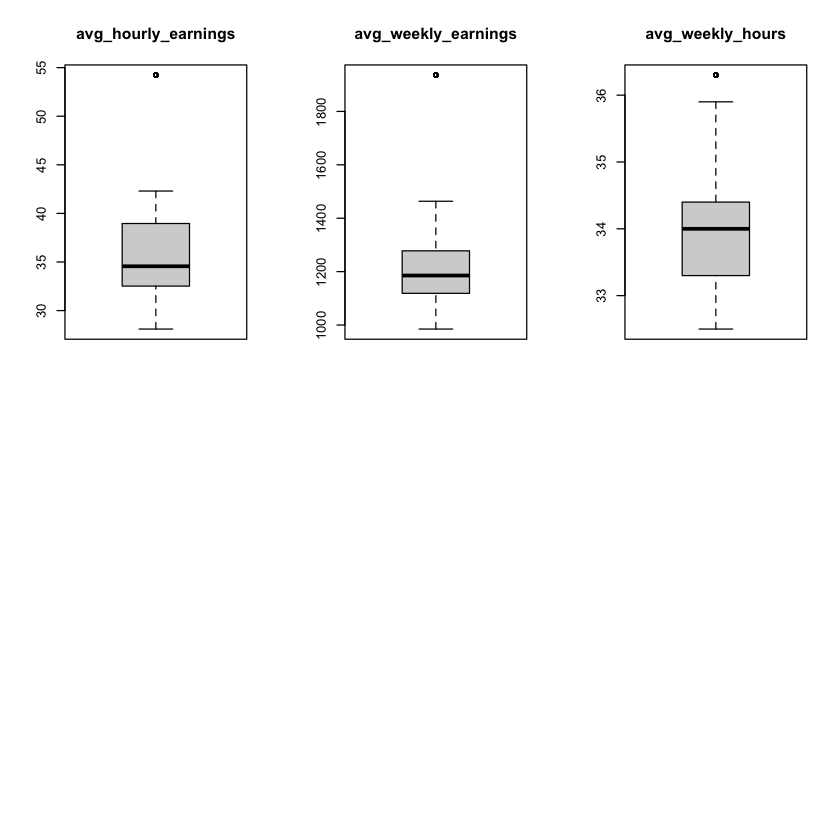

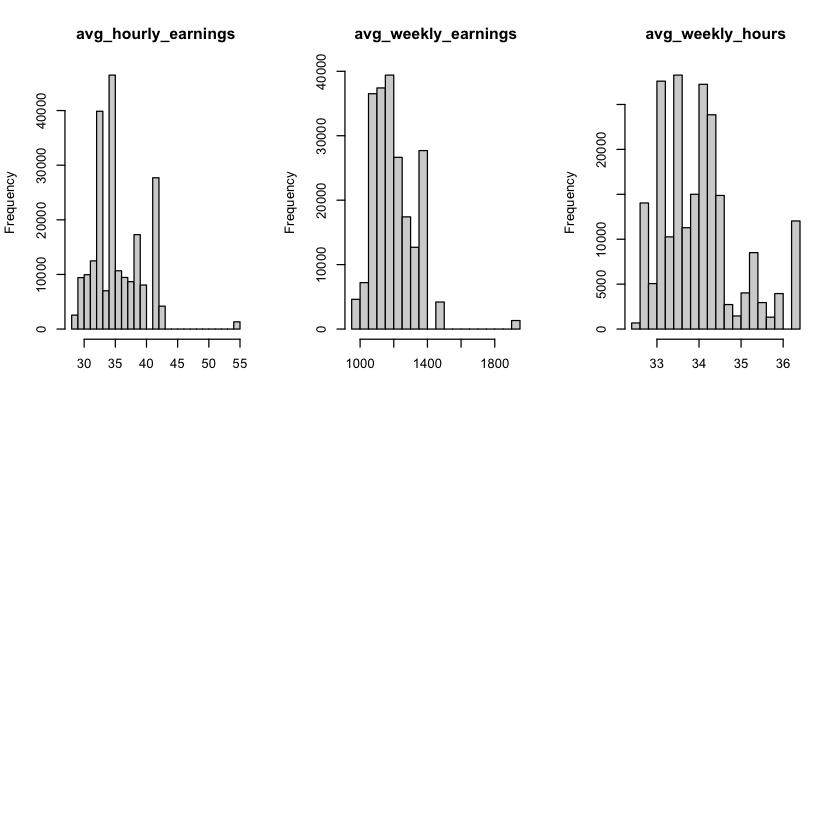

In [10]:
inspect_income <- eda_df %>%
select('avg_hourly_earnings', 'avg_weekly_earnings', 'avg_weekly_hours',)
# boxplots
par(mfrow = c(2,3))
for(col in names(inspect_income ))
    boxplot(inspect_income [[col]], main = col)

# histogram
par(mfrow = c(2,3))
for(col in names(inspect_income)) 
    hist(inspect_income[[col]], main = col, xlab = "")

#### Interpretation:
The distributions for income-related variables are relatively symmetric. There are some outliers, but they will be included in the analysis because they may describe a relationship between income and state.

#### Keep State Level Variables:

In [11]:
analysis_df <- df

## All Columns:
# 'UNITID''OPEID6.x''INSTNM.x''CIPCODE''CIPDESC''CREDLEV''CREDDESC''OPEID''OPEID6.y''INSTNM.y''CITY''STABBR''ZIP'
# 'CONTROL''REGION''TUITFTE''INEXPFTE''TUITIONFEE_IN''TUITIONFEE_OUT''ROOMBOARD_OFF''OTHEREXPENSE_OFF''BOOKSUPPLY'
# 'UGDS''UGDS_MEN''UGDS_WOMEN''UGDS_WHITE''UGDS_BLACK''UGDS_HISP''UGDS_ASIAN''UGDS_AIAN''UGDS_NHPI''UGDS_2MOR'
# 'UGDS_NRA''UGDS_UNKN''avg_hourly_earnings''avg_weekly_earnings''avg_weekly_hours''Debt_24''Borrowers_24''Debt_25-34'
# 'Borrowers_25-34''Debt_35-49''Borrowers_35-49''Debt_50-61''Borrowers_50-61''Debt_62_Plus''Borrowers_62_Plus'
# 'Total_Debt''Annual_Income''Debt_to_Income_Ratio''''

analysis_df <- analysis_df %>%
select(
    STABBR, # state 
    CREDDESC, 
    CONTROL,
    TUITFTE,
    TUITIONFEE_IN,
    TUITIONFEE_OUT,
    ROOMBOARD_OFF,
    OTHEREXPENSE_OFF,
    BOOKSUPPLY,
    Total_Debt,
    Annual_Income,
    Debt_to_Income_Ratio, # response    
  ) %>%
  filter(!is.na(STABBR), #filter NA 
         !is.na(Debt_to_Income_Ratio))

#### Interpretation: 

Aggregating by state will help us understand which factors explain differences in debt-to-income ratios by state. 

It is essential to keep columns that connect at a state level. Taking the average of each predictor across states will help explain its influence on debt-to-income ratios.

#### Group by STABBR:

In [12]:

analysis_df <- analysis_df %>%
group_by(STABBR) %>%
summarize(
    avg_ratio = mean(Debt_to_Income_Ratio, na.rm=TRUE),
    avg_tuition = mean(TUITFTE, na.rm=TRUE),
    avg_instate = mean(TUITIONFEE_IN, na.rm=TRUE),
    avg_outstate = mean(TUITIONFEE_OUT, na.rm=TRUE),
    avg_roomboard = mean(ROOMBOARD_OFF, na.rm=TRUE),
    avg_otherexp = mean(OTHEREXPENSE_OFF, na.rm=TRUE),
    avg_books = mean(BOOKSUPPLY, na.rm=TRUE),
    avg_totaldebt = mean(Total_Debt, na.rm=TRUE),
    avg_income = mean(Annual_Income, na.rm=TRUE)
  )

head(analysis_df, 10)

STABBR,avg_ratio,avg_tuition,avg_instate,avg_outstate,avg_roomboard,avg_otherexp,avg_books,avg_totaldebt,avg_income
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AK,31485.13,8175.045,9232.635,21153.07,11322.273,5751.494,1429.635,2.1800e+09,69239.04
AL,368425.98,9485.071,11902.341,19264.00,9632.552,4485.413,1380.721,2.1410e+10,58112.08
AR,221452.91,5735.084,9098.558,13440.64,8684.535,5318.466,1277.136,1.1870e+10,53600.56
AZ,467354.86,7784.221,7535.006,16057.56,9278.634,5740.157,1289.798,2.9100e+10,62265.32
CA,1888694.74,9181.051,12270.178,20435.73,15831.749,4572.303,1374.194,1.3398e+11,70937.88
CO,388910.86,12733.212,15190.139,25936.07,11406.120,4016.558,1447.119,2.6510e+10,68164.72
CT,222798.99,12203.120,22891.384,34429.36,11727.411,3640.105,1080.936,1.5170e+10,68088.28
DC,60989.83,24820.725,41775.255,42273.87,14788.477,2559.454,1279.468,6.1400e+09,100672.52
DE,76483.97,13668.025,13763.057,24760.42,11337.102,2666.706,1416.331,4.2500e+09,55567.20


#### Group by STABBR and CREDDESC:

In [13]:
analysis_df_2 <- df %>%
group_by(STABBR, CREDDESC) %>%
summarize(
    avg_ratio = mean(Debt_to_Income_Ratio, na.rm = TRUE),
    avg_tuition = mean(TUITFTE, na.rm = TRUE),
    avg_instate = mean(TUITIONFEE_IN, na.rm = TRUE),
    avg_outstate = mean(TUITIONFEE_OUT, na.rm = TRUE),
    avg_roomboard = mean(ROOMBOARD_OFF, na.rm = TRUE),
    avg_otherexp = mean(OTHEREXPENSE_OFF, na.rm = TRUE),
    avg_books = mean(BOOKSUPPLY, na.rm = TRUE),
    avg_totaldebt = mean(Total_Debt, na.rm = TRUE),
    avg_income = mean(Annual_Income, na.rm = TRUE),
    .groups = "drop"
  )
analysis_df_2

STABBR,CREDDESC,avg_ratio,avg_tuition,avg_instate,avg_outstate,avg_roomboard,avg_otherexp,avg_books,avg_totaldebt,avg_income
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AK,Associate's Degree,31485.13,7691.829,9188.119,19723.136,10957.305,5870.271,1237.288,2.180e+09,69239.04
AK,Bachelor's Degree,31485.13,8499.537,9822.030,22215.591,11375.067,5907.250,1449.512,2.180e+09,69239.04
AK,Doctoral Degree,31485.13,8681.864,7924.909,21642.909,12099.364,4642.364,1901.818,2.180e+09,69239.04
AK,First Professional Degree,31485.13,9909.500,14691.000,22994.000,13684.000,6448.000,1260.000,2.180e+09,69239.04
AK,Graduate/Professional Certificate,31485.13,8613.054,9207.405,22816.541,11627.243,5926.865,1572.973,2.180e+09,69239.04
AK,Master's Degree,31485.13,8643.213,8892.303,22264.888,11764.888,5390.438,1654.831,2.180e+09,69239.04
AK,Post-baccalaureate Certificate,31485.13,9473.333,12186.000,22433.333,13139.333,5715.333,1506.667,2.180e+09,69239.04
AK,Undergraduate Certificate or Diploma,31485.13,7697.219,8794.299,19779.628,10964.679,5819.453,1309.781,2.180e+09,69239.04
AL,Associate's Degree,368425.98,4120.662,6350.064,9752.143,7299.486,3676.346,1572.649,2.141e+10,58112.08


#### Interpretation: 

Aggregating by state and degree type to explore potential differences in model performance due to the grouping of data.

#### Train and Test Data:

In [14]:
set.seed(111)

# 70/30 split
train_split <- sample(1:nrow(analysis_df), size = floor(0.7 * nrow(analysis_df)))

trainData_prelim <- analysis_df[train_split, ]
testData_prelim  <- analysis_df[-train_split, ]



#### Interpretation: 
Creating two sets of training data. One grouped by State and one grouped by state and degree type.

#### Save Train and Test Data:

In [15]:
trainData_prelim <- write_csv(trainData_prelim, "~/Documents/ISYE_6414_Final_Project-Adrian/1_data_loading_cleaning/merged_data/trainData_prelim.csv")

In [16]:
testData_prelim <- write_csv(testData_prelim, "~/Documents/ISYE_6414_Final_Project-Adrian/1_data_loading_cleaning/merged_data/testData_prelim.csv")

In [17]:
analysis_df_2 <- df %>%
  group_by(STABBR, CREDDESC) %>%   
  summarize(
    avg_ratio     = mean(Debt_to_Income_Ratio, na.rm = TRUE),
    avg_tuition   = mean(TUITFTE, na.rm = TRUE),
    avg_instate   = mean(TUITIONFEE_IN, na.rm = TRUE),
    avg_outstate  = mean(TUITIONFEE_OUT, na.rm = TRUE),
    avg_roomboard = mean(ROOMBOARD_OFF, na.rm = TRUE),
    avg_otherexp  = mean(OTHEREXPENSE_OFF, na.rm = TRUE),
    avg_books     = mean(BOOKSUPPLY, na.rm = TRUE),
    avg_totaldebt = mean(Total_Debt, na.rm = TRUE),
    avg_income    = mean(Annual_Income, na.rm = TRUE),
    .groups = "drop"
  )
analysis_df_2

STABBR,CREDDESC,avg_ratio,avg_tuition,avg_instate,avg_outstate,avg_roomboard,avg_otherexp,avg_books,avg_totaldebt,avg_income
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AK,Associate's Degree,31485.13,7691.829,9188.119,19723.136,10957.305,5870.271,1237.288,2.180e+09,69239.04
AK,Bachelor's Degree,31485.13,8499.537,9822.030,22215.591,11375.067,5907.250,1449.512,2.180e+09,69239.04
AK,Doctoral Degree,31485.13,8681.864,7924.909,21642.909,12099.364,4642.364,1901.818,2.180e+09,69239.04
AK,First Professional Degree,31485.13,9909.500,14691.000,22994.000,13684.000,6448.000,1260.000,2.180e+09,69239.04
AK,Graduate/Professional Certificate,31485.13,8613.054,9207.405,22816.541,11627.243,5926.865,1572.973,2.180e+09,69239.04
AK,Master's Degree,31485.13,8643.213,8892.303,22264.888,11764.888,5390.438,1654.831,2.180e+09,69239.04
AK,Post-baccalaureate Certificate,31485.13,9473.333,12186.000,22433.333,13139.333,5715.333,1506.667,2.180e+09,69239.04
AK,Undergraduate Certificate or Diploma,31485.13,7697.219,8794.299,19779.628,10964.679,5819.453,1309.781,2.180e+09,69239.04
AL,Associate's Degree,368425.98,4120.662,6350.064,9752.143,7299.486,3676.346,1572.649,2.141e+10,58112.08


In [18]:
set.seed(111)

# 70/30 split
train_split <- sample(1:nrow(analysis_df_2), size = floor(0.7 * nrow(analysis_df_2 )))

trainData <- analysis_df_2 [train_split, ]
testData  <- analysis_df_2 [-train_split, ]


In [19]:
trainData <- write_csv(trainData, "~/Documents/ISYE_6414_Final_Project-Adrian/1_data_loading_cleaning/merged_data/trainData.csv")

In [20]:
testData <- write_csv(testData, "~/Documents/ISYE_6414_Final_Project-Adrian/1_data_loading_cleaning/merged_data/testData.csv")

## 3) Variable Selection Procedures:

### Preliminary Model: model1

**Predictors:**

avg_tuition

avg_instate

avg_outstate

avg_roomboard

avg_otherexp

avg_books

avg_totaldebt

avg_income

**Grouped by:** 

State (STABBR)

**Note:** 

This model includes all predictors.


In [21]:

model1 <- lm(avg_ratio ~ avg_tuition + avg_instate + avg_outstate + avg_roomboard + 
             avg_otherexp + avg_books + avg_totaldebt + avg_income, data = trainData_prelim)

summary(model1)



Call:
lm(formula = avg_ratio ~ avg_tuition + avg_instate + avg_outstate + 
    avg_roomboard + avg_otherexp + avg_books + avg_totaldebt + 
    avg_income, data = trainData_prelim)

Residuals:
   Min     1Q Median     3Q    Max 
-75718 -18135   -323  10391  69764 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    1.673e+05  7.924e+04   2.112  0.04446 *  
avg_tuition    9.478e-01  2.771e+00   0.342  0.73505    
avg_instate    2.967e+00  2.384e+00   1.244  0.22445    
avg_outstate  -6.158e-01  2.727e+00  -0.226  0.82313    
avg_roomboard -1.629e+01  5.779e+00  -2.819  0.00908 ** 
avg_otherexp   9.997e+00  8.340e+00   1.199  0.24149    
avg_books      5.407e+01  4.896e+01   1.104  0.27953    
avg_totaldebt  1.535e-05  2.264e-07  67.780  < 2e-16 ***
avg_income    -2.170e+00  1.040e+00  -2.086  0.04691 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 34230 on 26 degrees of freedom
Multiple R-squared:  0.996

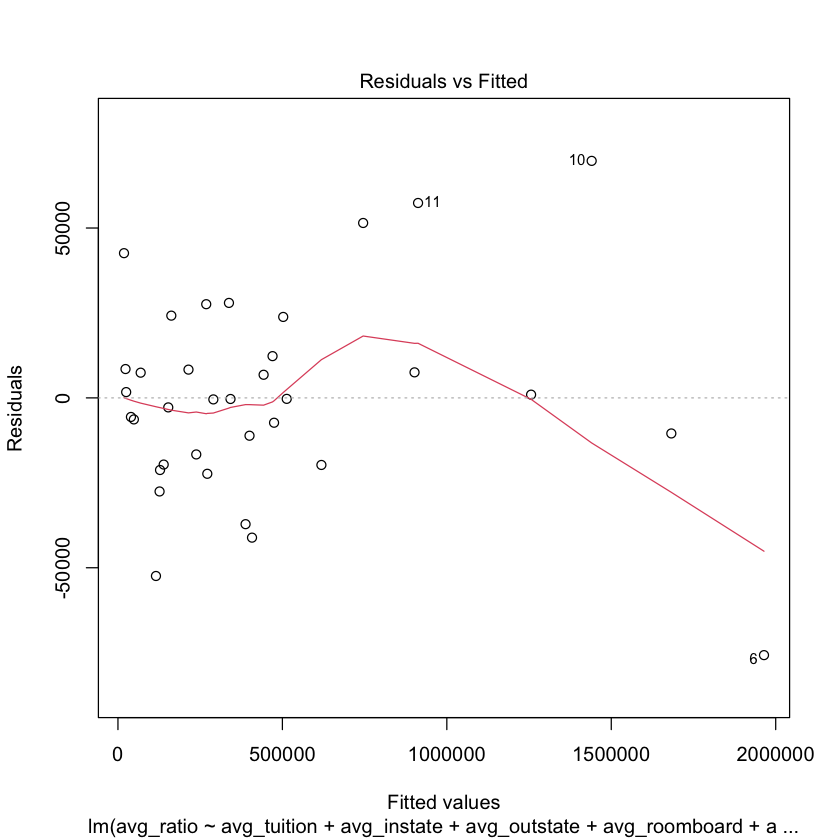

In [22]:
plot(model1, which = 1)

#### Interpretation:

Model 1: This served as a preliminary model, using all predictors and the grouped-by-state dataset. This model produced a suspiciously high R-squared of 0.9961, suggesting multicollinearity. The adjusted R-squared penalizes the number of predictors, yet it is also suspiciously high. The predictors appear to be correlated with one another. A potential problem is that the response variable (debt-to-income ratio) is calculated using predictors that capture average income and average debt.



### Reduced  Model: model2

**Predictors:**

avg_totaldebt

avg_income

**Grouped by:** 

State (STABBR)



In [23]:
model2 <- lm(avg_ratio ~ avg_totaldebt + avg_income, data = trainData_prelim)
summary(model2)


Call:
lm(formula = avg_ratio ~ avg_totaldebt + avg_income, data = trainData_prelim)

Residuals:
    Min      1Q  Median      3Q     Max 
-132117  -15529   -7521   18428   78339 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    2.192e+05  4.918e+04   4.457 9.55e-05 ***
avg_totaldebt  1.512e-05  2.138e-07  70.724  < 2e-16 ***
avg_income    -3.167e+00  7.774e-01  -4.074 0.000285 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 39450 on 32 degrees of freedom
Multiple R-squared:  0.9937,	Adjusted R-squared:  0.9933 
F-statistic:  2505 on 2 and 32 DF,  p-value: < 2.2e-16


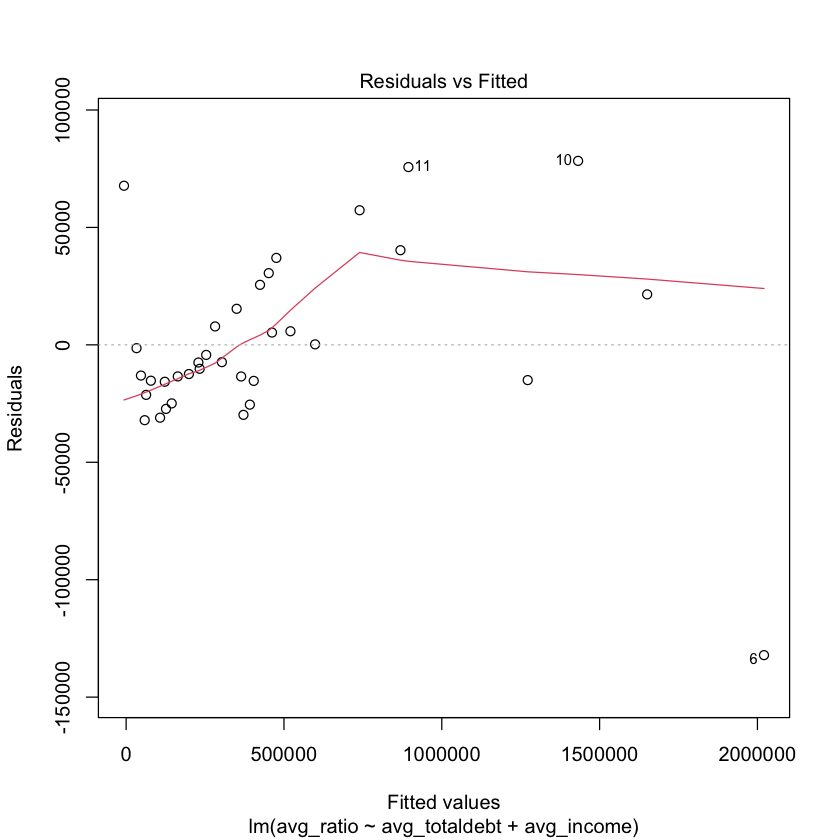

In [24]:
plot(model2, which = 1)

#### Interpretation:

Model 2: To confirm suspicions about the relationship between response and predictors in Model 1, this model only included the predictors used to calculate the response variable. As expected, there was a strong relationship. This model also exemplified a high R-squared value. This model does not uncover any new relationships between the predictors and response.


### Reduced Preliminary Model: model3 

**Predictors:**

avg_tuition

avg_instate

avg_outstate

avg_roomboard

avg_otherexp

avg_books

**Grouped by:** 

State (STABBR)

**Note:** 
Removed predictors contributing to the calculation of the debt-to-income ratio (response variable).

In [25]:
model3 <- lm(avg_ratio ~ avg_tuition + avg_instate + avg_outstate + avg_roomboard + 
             avg_otherexp + avg_books,  data = trainData_prelim)
summary(model3)


Call:
lm(formula = avg_ratio ~ avg_tuition + avg_instate + avg_outstate + 
    avg_roomboard + avg_otherexp + avg_books, data = trainData_prelim)

Residuals:
    Min      1Q  Median      3Q     Max 
-737997 -229441  -80895  114562 1228864 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)  
(Intercept)   -718705.37  786052.55  -0.914   0.3684  
avg_tuition       -36.88      35.09  -1.051   0.3021  
avg_instate        41.59      28.61   1.454   0.1572  
avg_outstate      -36.47      35.37  -1.031   0.3114  
avg_roomboard     134.72      54.07   2.492   0.0189 *
avg_otherexp       89.34     109.43   0.816   0.4211  
avg_books          12.87     601.67   0.021   0.9831  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 454400 on 28 degrees of freedom
Multiple R-squared:  0.2631,	Adjusted R-squared:  0.1052 
F-statistic: 1.666 on 6 and 28 DF,  p-value: 0.1663


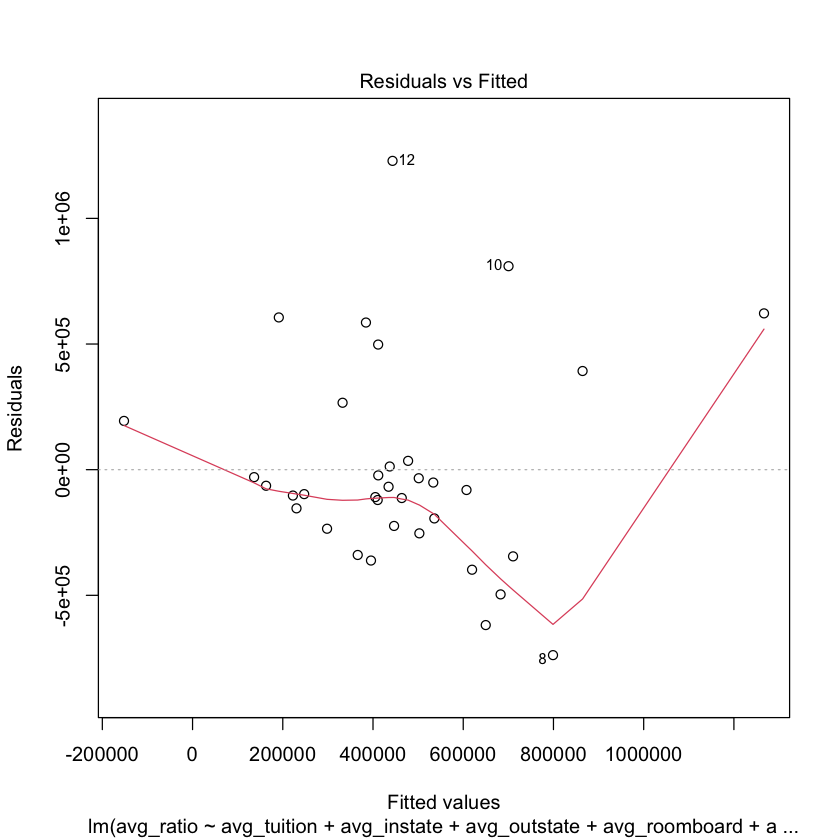

In [26]:
plot(model3, which = 1)

#### Interpretation: 

Model 3: To fully confirm suspicions of multicollinearity raised in Models 1 and 2, this approach tests all predictors except those used to create the response. One thing predictors have in common is that they are related to a cost, for instance, tuition, books, room and board, etc. The r-squared value was 0.2631, meaning that this combination of predicting variables explains about 26% of the variation in the response variable. The adjusted R-squared value, however, was 0.1052. This suggested that cost predictors alone did not display strong predictive power.

### Grouped by State and Institution Type:  model4 

**Predictors:**

avg_tuition

avg_instate 

avg_outstate 

avg_roomboard 

avg_otherexp

avg_books

avg_totaldebt

avg_income 

CREDDESC 

**Grouped by:** 

State(STABBR) 
CREDDESC (School Type)

**Note:** 
Removed predictores contributing to the calculation of the debt to income ratio (response variable)

In [27]:
model4 <- lm(
  avg_ratio ~ avg_tuition + avg_instate + avg_outstate + avg_roomboard + 
             avg_otherexp + avg_books + avg_totaldebt + avg_income + CREDDESC , data = trainData)
summary(model4)


Call:
lm(formula = avg_ratio ~ avg_tuition + avg_instate + avg_outstate + 
    avg_roomboard + avg_otherexp + avg_books + avg_totaldebt + 
    avg_income + CREDDESC, data = trainData)

Residuals:
    Min      1Q  Median      3Q     Max 
-148048  -15500   -1976   14626   85109 

Coefficients:
                                               Estimate Std. Error t value
(Intercept)                                   2.403e+05  2.596e+04   9.258
avg_tuition                                  -1.730e-01  2.440e-01  -0.709
avg_instate                                   1.703e+00  5.235e-01   3.252
avg_outstate                                  3.133e-01  6.225e-01   0.503
avg_roomboard                                -8.680e+00  1.615e+00  -5.375
avg_otherexp                                  3.728e+00  2.544e+00   1.466
avg_books                                     2.630e+01  1.259e+01   2.089
avg_totaldebt                                 1.532e-05  8.178e-08 187.393
avg_income                     

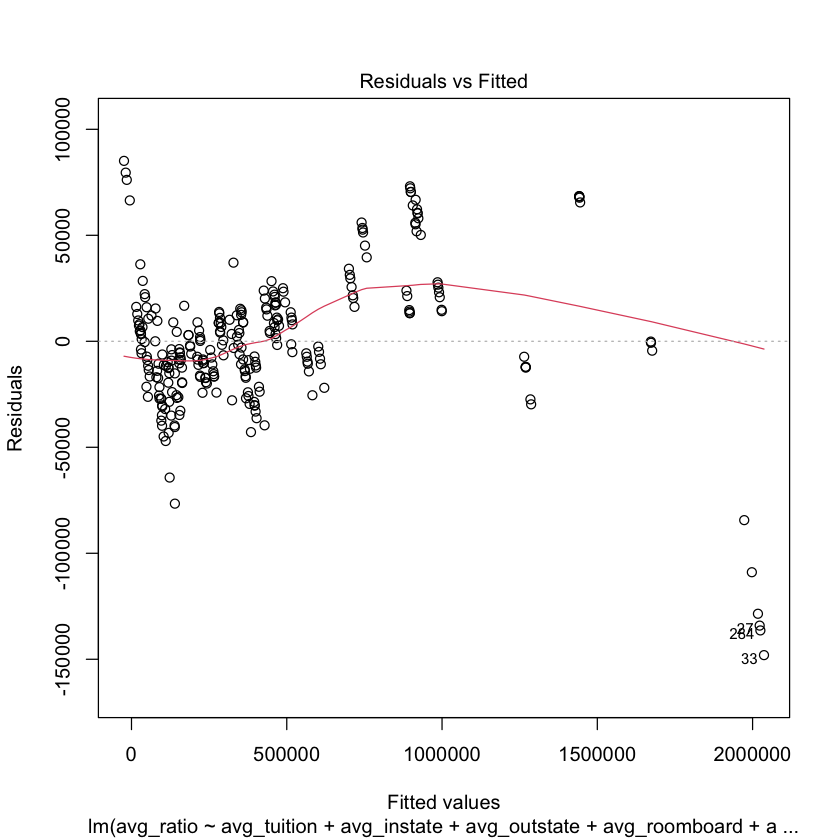

In [28]:
plot(model4, which = 1)

#### Interpretation: 

Model 4: This model emulates Model 1 by using all predictors except those used to calculate the response variable. This model uses data grouped by state and degree type. Similar to Model 2, it shows a very high R-squared value, reflecting the strong relationship between the predictors and the response.

### Reduced Model: model5

**Predictors:**

avg_tuition

avg_instate 

avg_outstate 

avg_roomboard 

avg_otherexp

avg_books

CREDDESC 


**Grouped by:** 

State(STABBR) 
CREDDESC (School Type)

**Note:** 

Removed predictors contributing to the calculation of the debt-to-income ratio (response variable).

In [29]:
model5 <- lm(
  avg_ratio ~ avg_tuition + avg_instate + avg_outstate + avg_roomboard + 
             avg_otherexp + avg_books + CREDDESC, data = trainData)
summary(model5)


Call:
lm(formula = avg_ratio ~ avg_tuition + avg_instate + avg_outstate + 
    avg_roomboard + avg_otherexp + avg_books + CREDDESC, data = trainData)

Residuals:
    Min      1Q  Median      3Q     Max 
-873711 -215073  -72488  141153 1241500 

Coefficients:
                                               Estimate Std. Error t value
(Intercept)                                  -4.414e+05  2.263e+05  -1.950
avg_tuition                                  -5.691e+00  2.783e+00  -2.045
avg_instate                                   2.284e+01  5.778e+00   3.953
avg_outstate                                 -8.390e+00  7.181e+00  -1.168
avg_roomboard                                 5.191e+01  1.647e+01   3.152
avg_otherexp                                  9.099e+01  2.893e+01   3.145
avg_books                                     4.045e+00  1.446e+02   0.028
CREDDESCBachelor's Degree                    -2.831e+05  1.119e+05  -2.530
CREDDESCDoctoral Degree                      -8.254e+04  1.307e+0

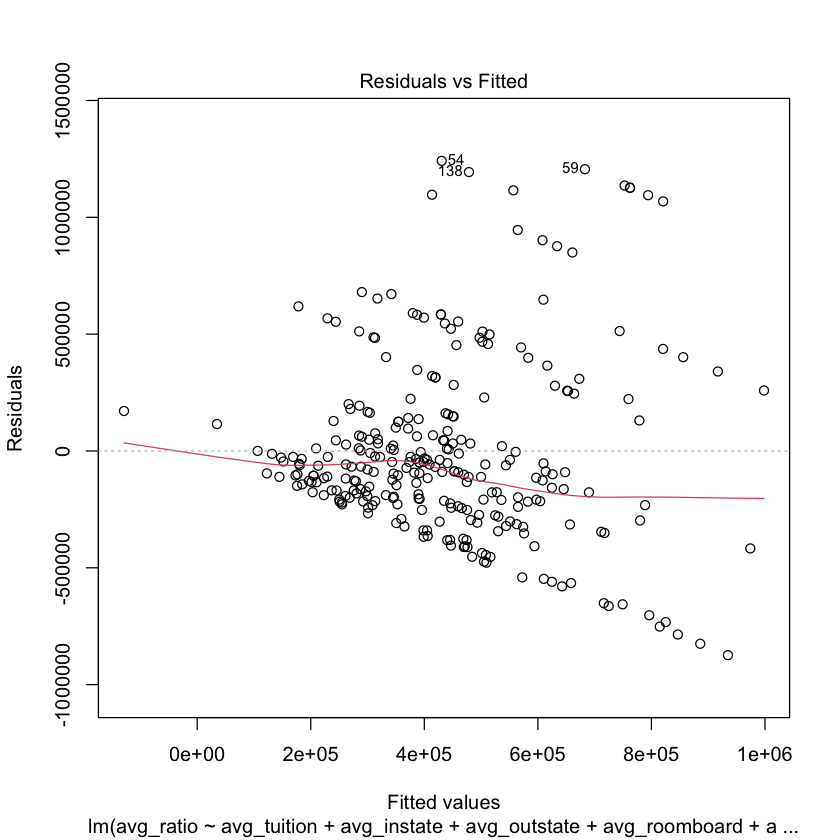

In [30]:
plot(model5, which = 1)

#### Interpretation:

Model 5: This model uses cost-related predictors, except those used to calculate the response variable. In addition, a new predictor, CREDDES, is introduced, which describes the degree to which an institution grants. This model has an R-squared value of 0.1807, indicating that it explains about 18% of the variation in the data. In addition, the adjusted R-squared does not drop significantly when penalizing for the number of predictors. 

This model is used as the base model for this analysis, given its reasonable R-squared value and its statistically significant predictors. Model 5 showed that cost-related variables were not statistically significant. This reduced the predictors to 4 main predicting variables: average tuition, average in-state tuition, average room and board, and average other expenses. 


#### Summary:

Model 1: A preliminary model that includes all predictors, including avg_totaldebt and avg_income, which makes it invalid for this analysis.

Model 2: Uses avg_totaldebt and avg_income as predictors. However, avg_totaldebt and avg_income are used to create the response variable. This is an invalid approach given that the relationships in the predictors directly influence the response variable. This results in multicollinearity.

Model 3: Demonstrates an R-squared value of 0.2631, indicating that this set of predictor variables explains about 26% of the variation in the response variable. However, the adjusted R-squared value was 0.1052. This suggested that cost predictors alone did not display strong predictive power.

Model 4: A valid approach, but it may be multicollinear.

Model 5: Given the goal of identifying which factors influence the debt-to-income ratio at the state level, Model 5 is the most appropriate. Model 5 does not include avg_totaldebt and avg_income; it includes tuition-related and institution variables. Model 5 offers a great starting point. This model is built on variables relating to costs, such as avg_tuition, avg_instate, avg_outstate, avg_roomboard, and avg_books, as well as a dedicated variable that tracks institution type (CREDDESC).

### 4) Goodness of Fit Testing and Model Assumption Checks:

### Regression Assumptions:
1) Linearity 
2) Constant Variance 
3) Normality
4) Independent Errors

#### 1) Check for Linearity:

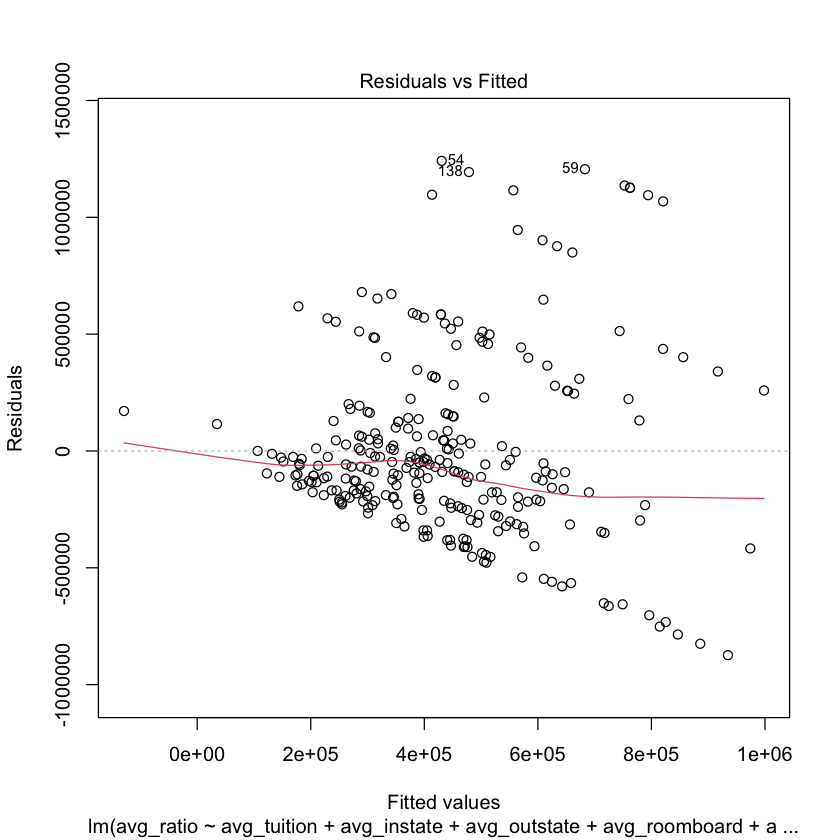

In [31]:
plot(model5, which = 1)

#### Interpretation:
Linearity is violated. The residuals demonstrate a slight curve. The spread of the residuals in larger values suggests heteroscedasticity. Given that the residuals are not centered around zero, the relationship between the predictors and the response variable is nonlinear.  To improve linearity, I will identify and remove influential points below.

#### Cookes Distance:

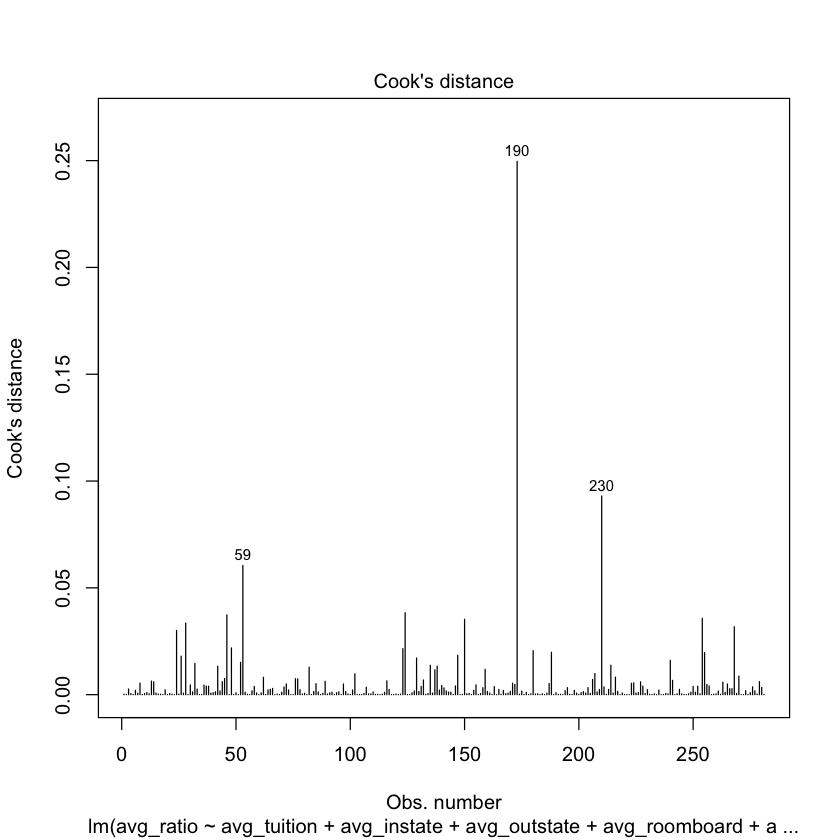

In [32]:
plot(model5, which = 4)
# Helps to see if outliers are skewing results.

In [33]:
cooks_distance <- cooks.distance(model5)
which(cooks_distance > 4/length(cooks_distance)) # Module 2

27  31  33  38  52  54  58  59 138 139 144 163 166 190 198 206 230 266 284 285 
 24  26  28  32  46  48  52  53 123 124 129 147 150 173 180 188 210 240 254 255 
298 
268

#### Remove Influencal Points:

In [34]:
cooks_distance <- cooks.distance(model5)
influ_points <- which(cooks_distance > 0.15) # 4/n is too strict, 0.15 will remove strong influences
influ_points

190 
173

#### Interpretation

To improve linearity, I have used Cook's distance to identify potential influential points and used the threshold of 0.15 to remove strong influences.  



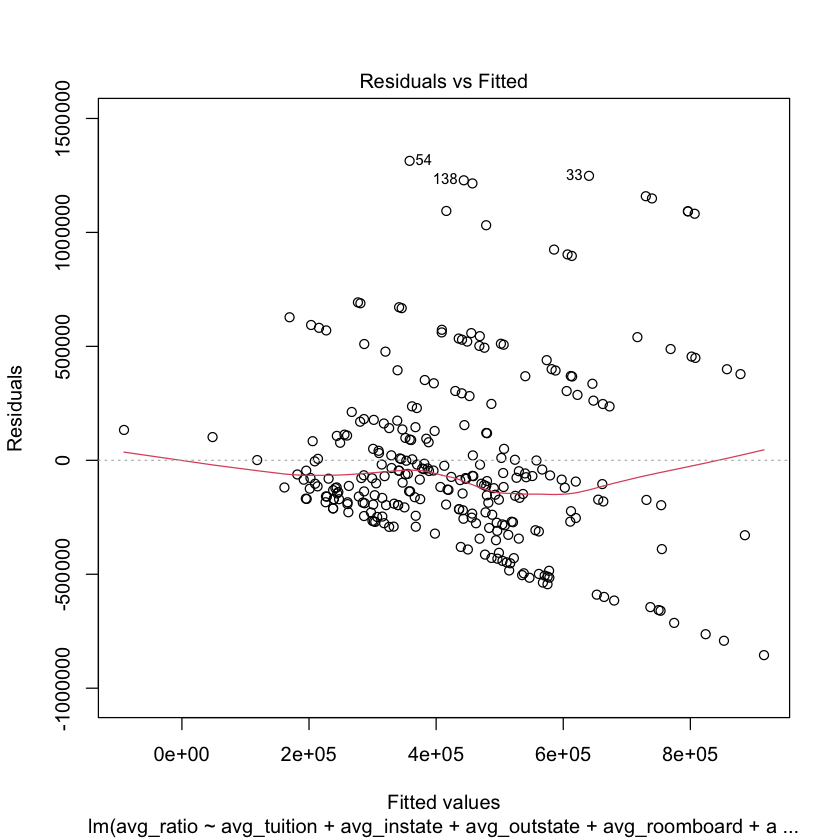

In [35]:
train_clean <- trainData[-influ_points, ] # data without influential points  

model5_clean <- lm(avg_ratio ~ avg_tuition + avg_instate + avg_outstate +
                   avg_roomboard + avg_otherexp + avg_books, data = train_clean)

plot(model5_clean, which = 1)

#### Apply Log Transformation:


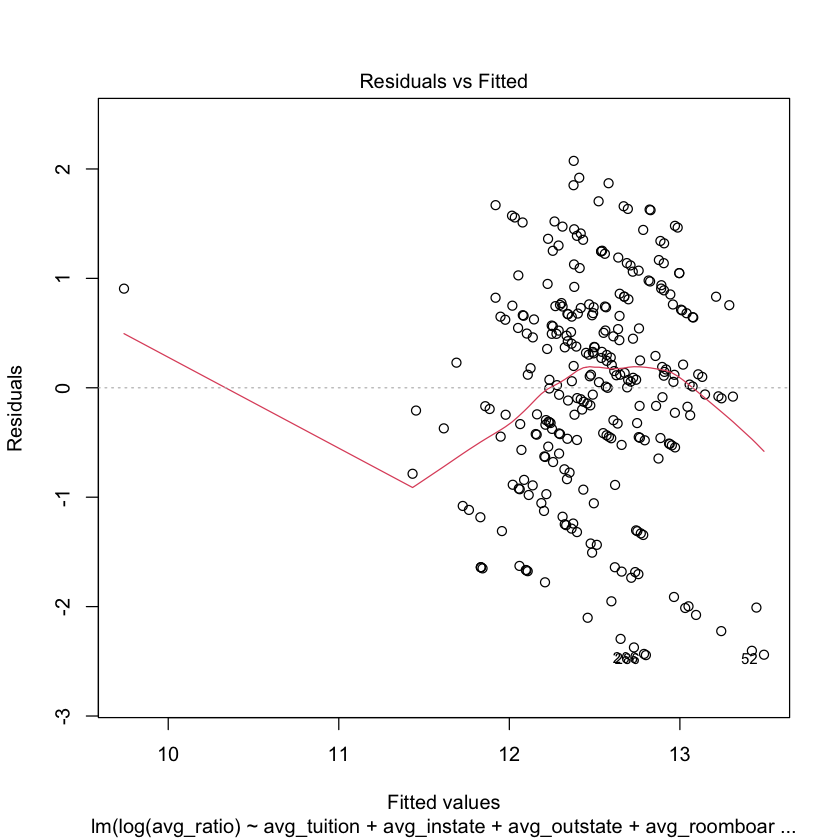

In [36]:
model_log <- lm(log(avg_ratio) ~ avg_tuition + avg_instate + avg_outstate +
                avg_roomboard + avg_otherexp + avg_books,
                data=train_clean)
plot(model_log, which=1)

In [37]:
summary(model_log)


Call:
lm(formula = log(avg_ratio) ~ avg_tuition + avg_instate + avg_outstate + 
    avg_roomboard + avg_otherexp + avg_books, data = train_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4434 -0.5233  0.1022  0.7176  2.0739 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    1.071e+01  5.577e-01  19.201  < 2e-16 ***
avg_tuition   -2.233e-05  7.070e-06  -3.158  0.00177 ** 
avg_instate    5.848e-05  1.379e-05   4.242 3.04e-05 ***
avg_outstate  -1.221e-05  1.452e-05  -0.841  0.40104    
avg_roomboard  4.876e-06  4.198e-05   0.116  0.90762    
avg_otherexp   2.693e-04  7.092e-05   3.797  0.00018 ***
avg_books      2.293e-04  3.497e-04   0.656  0.51264    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.008 on 273 degrees of freedom
  (33 observations deleted due to missingness)
Multiple R-squared:  0.1393,	Adjusted R-squared:  0.1204 
F-statistic: 7.366 on 6 and 273 DF,  p-value: 2.576e-07


#### Interpretation:
Keep only variables that are statistically significant. 
avg_tuition, avg_tuition, and avg_otherexp are statistically significant.


In [38]:
model_log_sig <- lm(log(avg_ratio) ~ avg_tuition + avg_instate + avg_otherexp,
                     data = train_clean)
summary(model_log_sig)


Call:
lm(formula = log(avg_ratio) ~ avg_tuition + avg_instate + avg_otherexp, 
    data = train_clean)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.45123 -0.57902  0.08934  0.72298  2.19322 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.088e+01  3.446e-01  31.570  < 2e-16 ***
avg_tuition  -2.402e-05  6.761e-06  -3.553 0.000448 ***
avg_instate   4.868e-05  8.249e-06   5.901 1.05e-08 ***
avg_otherexp  2.804e-04  6.853e-05   4.092 5.63e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.005 on 276 degrees of freedom
  (33 observations deleted due to missingness)
Multiple R-squared:  0.1343,	Adjusted R-squared:  0.1249 
F-statistic: 14.27 on 3 and 276 DF,  p-value: 1.139e-08


#### Interpretation: 

I simplified model_log and created model_log_sig which is composed of predictors that demonstrated statistical significance.

To address the violation of the linearity assumption, I applied a log transformation to flatten the scale to make the linearity assumption more apparent (similar to the log transformation applied on the Palm Beach County example in class). The linearity assumption is better, the errors are scattered around 0, and the megaphone shape has subsided. I will first check for constant variance and normality below.

#### 2) Check for Constant Variance:

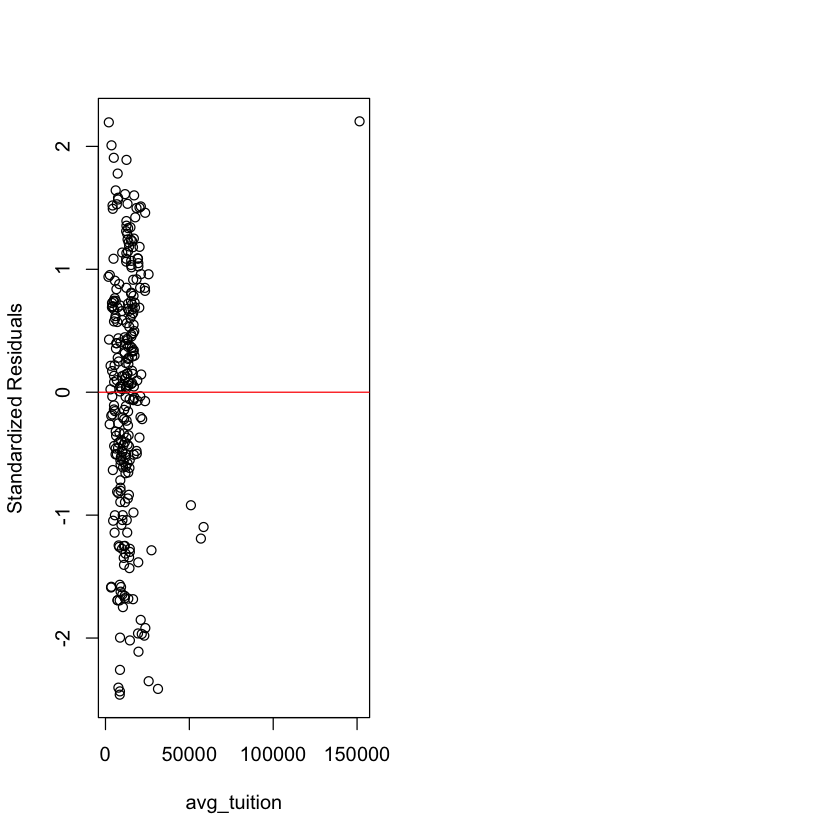

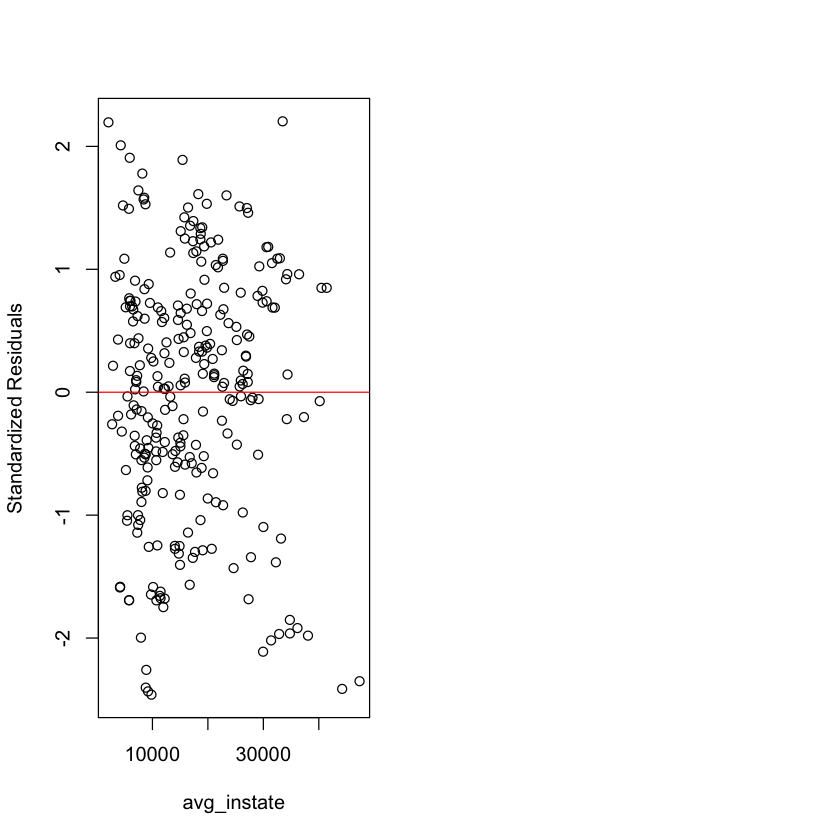

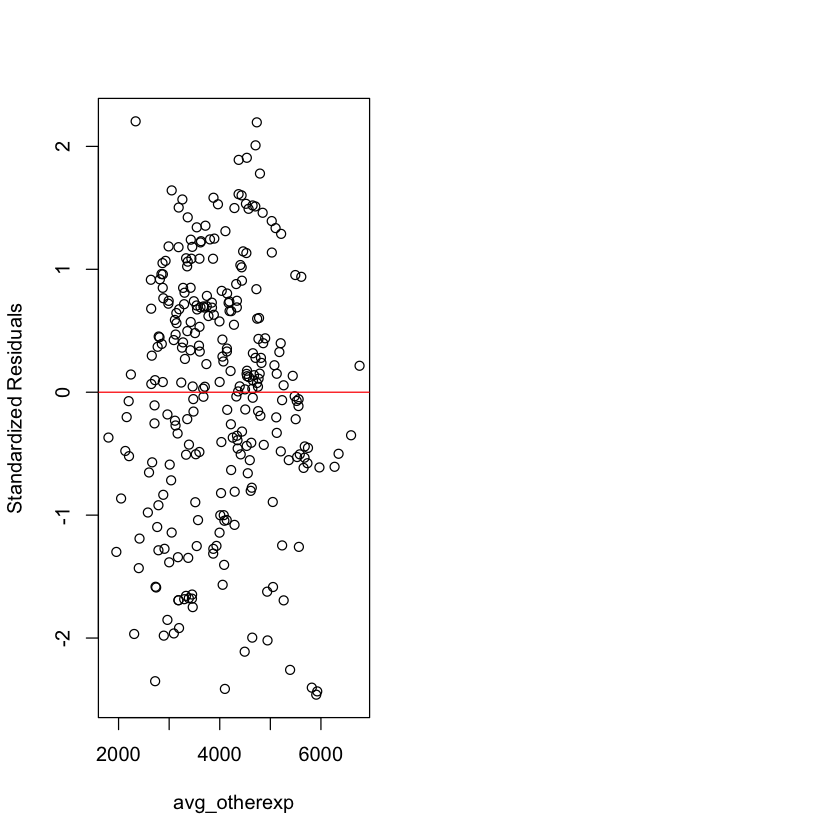

In [39]:

df_used <- model.frame(model_log_sig) # get model fram from model_log_sig

model_log_sig_resids <- rstandard(model_log_sig)

par(mfrow = c(1, 2))
plot(df_used$avg_tuition, model_log_sig_resids,
     xlab = "avg_tuition", ylab = "Standardized Residuals")
abline(h = 0, col = "red")

par(mfrow = c(1, 2))
plot(df_used$avg_instate, model_log_sig_resids,
     xlab = "avg_instate", ylab = "Standardized Residuals")
abline(h = 0, col = "red")

par(mfrow = c(1, 2))
plot(df_used$avg_otherexp, model_log_sig_resids,
     xlab = "avg_otherexp", ylab = "Standardized Residuals")
abline(h = 0, col = "red")


#### Interpretation:

Constant variance assumption is met. Avg_tuition demonstrated a consistent spread from -2 to 2 with no megaphone or funnel-shaped patterns. Avg_instate demonstrated a consistent spread without any patterns. 
Avg_otherexp showed a consistent spread with no patterns. All three predictors pass the Constant Variance Assumption; therefore, errors demonstrate homoscedasticity.



### 3) Normality:

#### Scatterplot of the Standardized Residuals vs. the Fitted Values of model1:

286 266 
256 240

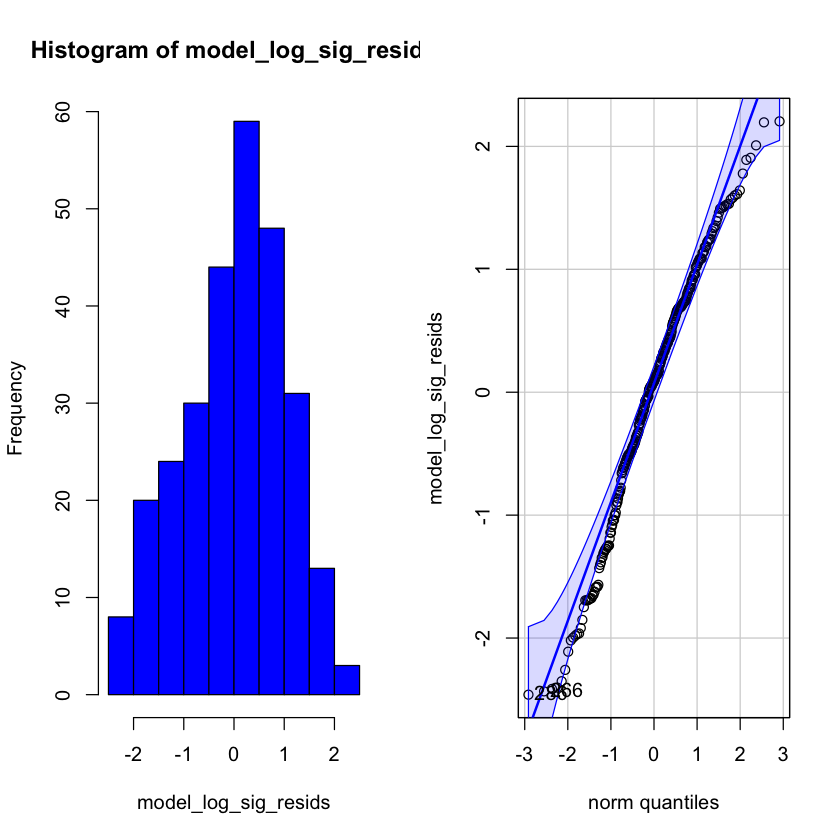

In [40]:
# QQ plot.
par(mfrow = c(1, 2))
hist(model_log_sig_resids, col = "blue")
qqPlot(model_log_sig_resids, envelope = 0.95)

#### Interpretation:
The residuals from the log-transformed model exhibit a normal distribution, as shown by the bell-shaped distribution in the barplot. The QQ plot shows that most points are within the shaded region.

#### Multicollinearity:

In [41]:
# VIF threshold.
cat("VIF threshold: ", max(10, 1/(1-summary(model_log_sig)$r.squared)), "\n")
# VIF.
vif(model_log_sig)

VIF threshold:  10 


avg_tuition  avg_instate avg_otherexp 
    1.485327     1.614049     1.196872

#### Interpretation:
To assess multicollinearity among predictors, I ran a VIF test. Multicollinearity occurs when variables are too closely related and therefore demonstrate the same relationship with the response variable. VIF is a way to determine whether multicollinearity is strong using a threshold of 2. Since all predictor variables are below 2, multicollinearity is not an issue.

### ANOVA:


In [42]:
anova(model_log_sig)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
avg_tuition,1,1.935645,1.935645,1.915119,1.675138e-01
avg_instate,1,24.406031,24.406031,24.147227,1.532211e-06
avg_otherexp,1,16.920714,16.920714,16.741285,5.627912e-05
Residuals,276,278.958097,1.010718,NA,NA


#### Interpretation: 

According to the ANOVA test avg_tuition is not significant when all predictors are in the model. ANOVA suggests that avg_tuition is collinear with avg_instate.  

In [43]:
car::vif(model_log_sig)


avg_tuition  avg_instate avg_otherexp 
    1.485327     1.614049     1.196872

Given that all VIF values are below the threshold of 2, there is no colinearity, but avg_instate is a weaker predictor.

#### F-test:
Given that the f value is relatively large at 14.27, it suggests that the predictors avg_tuition, avg_instate, and avg_other explain variation in the model.

#### P-value:
The p-value is low at 1.139e-08. This suggests that the model is statistically significant, implying that it is unlikely that the predictor does NOT influence the response variable.

#### R-squared:
The R-squared values are relatively low. At 0.1343, the R-squared value explains about 13 percent of the variance in the data. While the model is statistically significant based on its p-value, there are other factors unaccounted for in this model. 

### 5) Model training and Evaluation Code:

In [44]:
model_log_sig2 <- lm(log(avg_ratio) ~ avg_instate + avg_otherexp, data = train_clean) ### Simplify the model
summary(model_log_sig2)


Call:
lm(formula = log(avg_ratio) ~ avg_instate + avg_otherexp, data = train_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4890 -0.6133  0.1193  0.7635  2.2202 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.073e+01  3.493e-01  30.732  < 2e-16 ***
avg_instate  3.362e-05  7.223e-06   4.654 5.04e-06 ***
avg_otherexp 3.017e-04  6.968e-05   4.330 2.09e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.026 on 277 degrees of freedom
  (33 observations deleted due to missingness)
Multiple R-squared:  0.09467,	Adjusted R-squared:  0.08814 
F-statistic: 14.48 on 2 and 277 DF,  p-value: 1.041e-06


#### Interpretation:

The ANOVA test demonstrated that avg_tuition was not a significant predictor when paired with avg_instate and avg_otherexp. To simplify the model, I removed avg_tuition. 

I will explore this as model_log_sig2. Below, I will investigate the core assumptions relating to this reduced model.


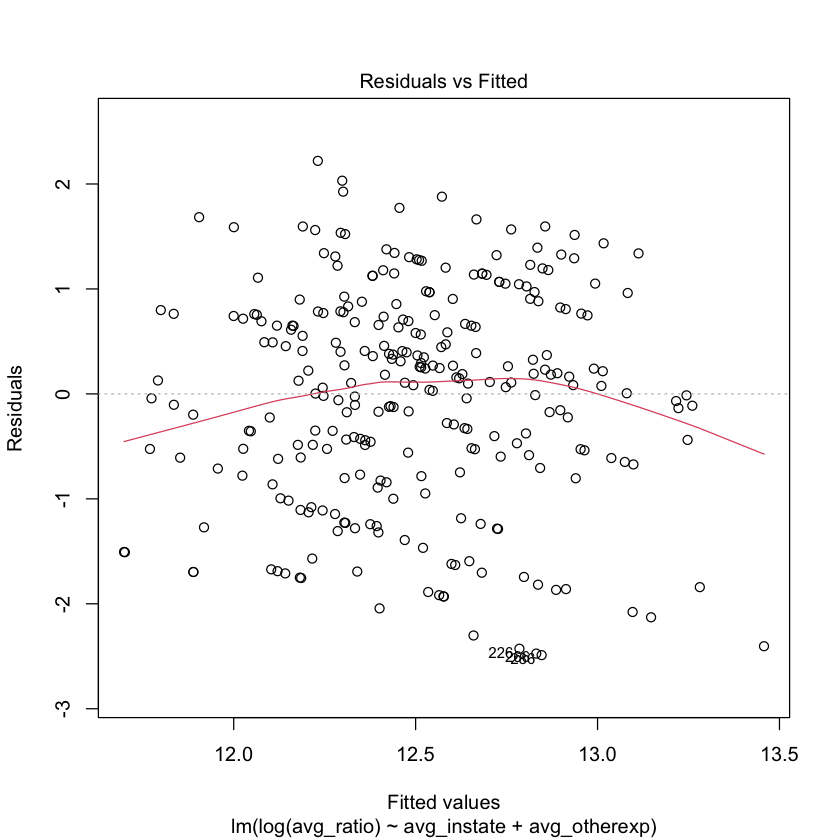

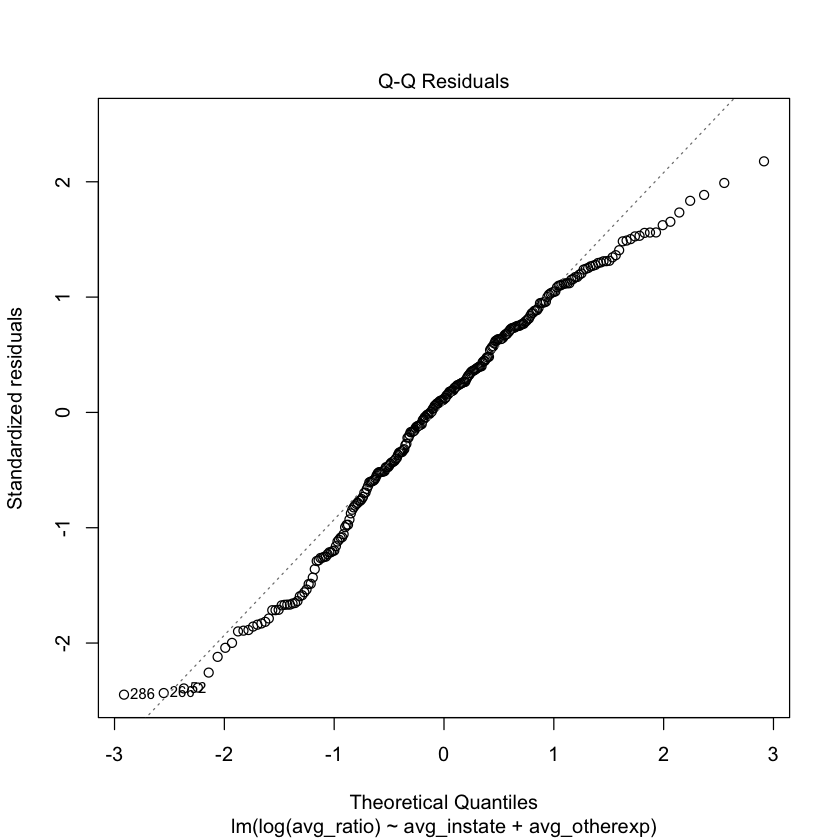

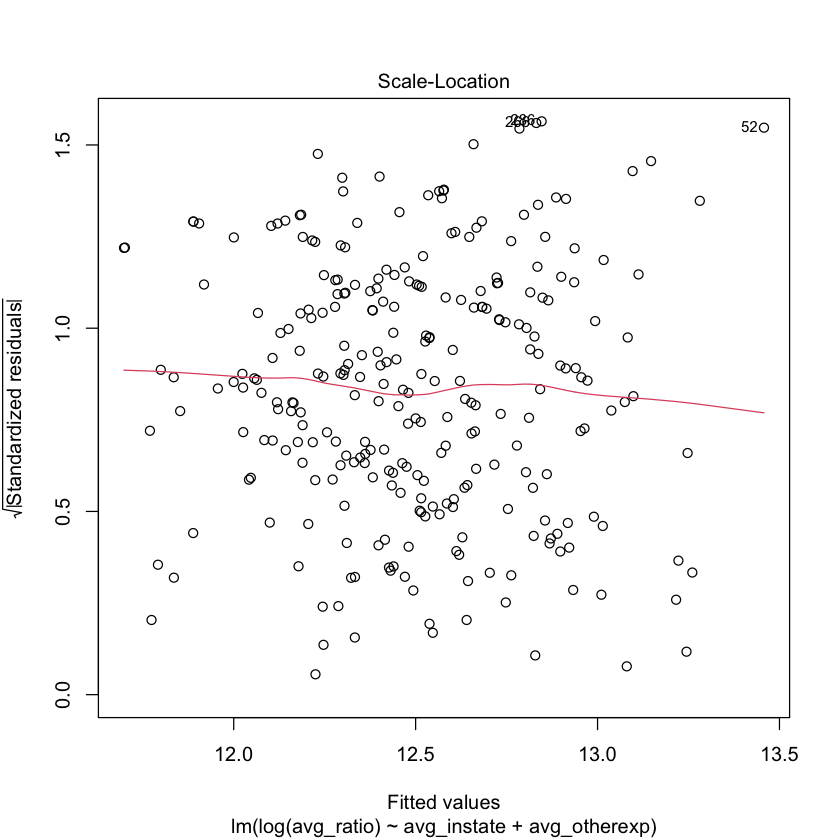

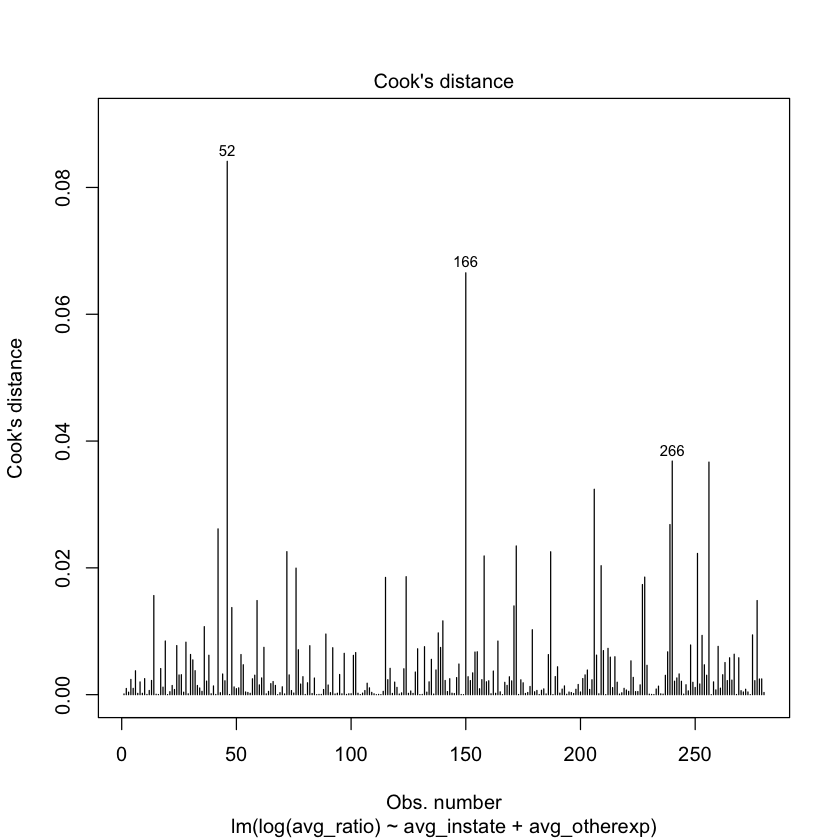

In [45]:
plot(model_log_sig2, which=1:4)

#### Interpretation: 
All regression assumptions are met under this reduced model; however, I will use cross-validation to help choose a final model.

## 6) Statistical Analysis and Hypothesis Testing:


I cannot apply deviance and pearson goodness of fit test to Multiple linear regression models.  

### Hyposthesis Testing:



Null Hypothesis: The null hypothesis is that the predictors avg_tuition, avg_instate, and avg_otherexp do not have a relationship with the response varible log(avg_ratio).


Alternative Hypothesis: The alternative hypothesis is that the predictors avg_tuition, avg_instate, and avg_otherexp do indeed have a relationship with the response varible log(avg_ratio).

Given that the p value is less than 0.05, it is reasonable to conclude that the predictors help predict the response. There the null hypothesis is rejected.

## 7) Cross-validation and Model Selection:

Need to get rid of NA values in response variable

In [46]:
colSums(is.na(train_clean))
sum(is.na(train_clean$avg_ratio))

STABBR      CREDDESC     avg_ratio   avg_tuition   avg_instate 
            6             0            33             6             6 
 avg_outstate avg_roomboard  avg_otherexp     avg_books avg_totaldebt 
            6             6             6             6            33 
   avg_income 
           33

[1] 33

#### Interpretation:
There are missing values in response and predictors. Simple solution is to drop NA values.

In [47]:
trainData_cv <- na.omit(train_clean)

In [48]:
library(caret)

train_control <- trainControl(method = "cv", number = 5)

# filtered with only significant values and ANOVA suggestion
cv_model_log_sig2 <- train( # only 2 predictors (takes into account ANOVA )
  formula(model_log_sig2),
  data = trainData_cv,
  method = "lm",
  trControl = train_control)

# filtered with only significant values 
cv_model_log_sig <- train( # 3 predictor 
  formula(model_log_sig),
  data = trainData_cv,
  method = "lm",
  trControl = train_control)

# unreduced model 
cv_model_log <- train(
  formula(model_log),
  data = trainData_cv,
  method = "lm",
  trControl = train_control)

cv_model_log_sig2
cv_model_log_sig
cv_model_log


Linear Regression 

280 samples
  2 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 224, 223, 225, 224, 224 
Resampling results:

  RMSE      Rsquared    MAE      
  1.024549  0.09391303  0.8366988

Tuning parameter 'intercept' was held constant at a value of TRUE

Linear Regression 

280 samples
  3 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 224, 223, 225, 224, 224 
Resampling results:

  RMSE      Rsquared   MAE      
  1.021152  0.1164187  0.8207335

Tuning parameter 'intercept' was held constant at a value of TRUE

Linear Regression 

280 samples
  6 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 224, 223, 225, 224, 224 
Resampling results:

  RMSE      Rsquared   MAE      
  1.071933  0.1078498  0.8378718

Tuning parameter 'intercept' was held constant at a value of TRUE

#### Interpretation:

To assess the model's performance on unseen data, I conducted 5-fold cross-validation. The base model is model_log, which applies a log transformation to its response variable (debt-to-income ratio) and averages it by state (avg_ratio).

model_log_sig is similar to model_log, but includes only predictors deemed statistically significant after reviewing p-values at the 0.05 significance threshold.

model_log_sig2 has only two predictors; it uses p-value-based tests and ANOVA results to justify the reduction in variables. 

While model_log_sig2 has the lowest RMSE of 1.027231, model_log_sig still better explains the data's variance. model_log_sig explains about 13% of the variance in the data.

In [49]:
final_model <- model_log_sig

model_log_sig is the final model.

In [50]:
# remove rows with missing values
testData <- na.omit(testData)

# prediction
predicted_log <- predict(final_model, newdata = testData)

predicted_ratio <- exp(predicted_log) # convert predictions back to debt-to-income ratio, since response is log()(same scale) 

In [51]:
head(predicted_ratio,5)

1        2        3        4        5 
357423.5 520884.2 379415.3 281090.3 273815.0

In [52]:
summary(trainData$avg_ratio)
summary(testData$avg_ratio)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  26696  119448  341891  438278  557097 1888695      33 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  26696   98995  295987  415810  512882 1888695 

#### Interpretation:
- Values are with in same magnitude.


#### Extra Visualizations:

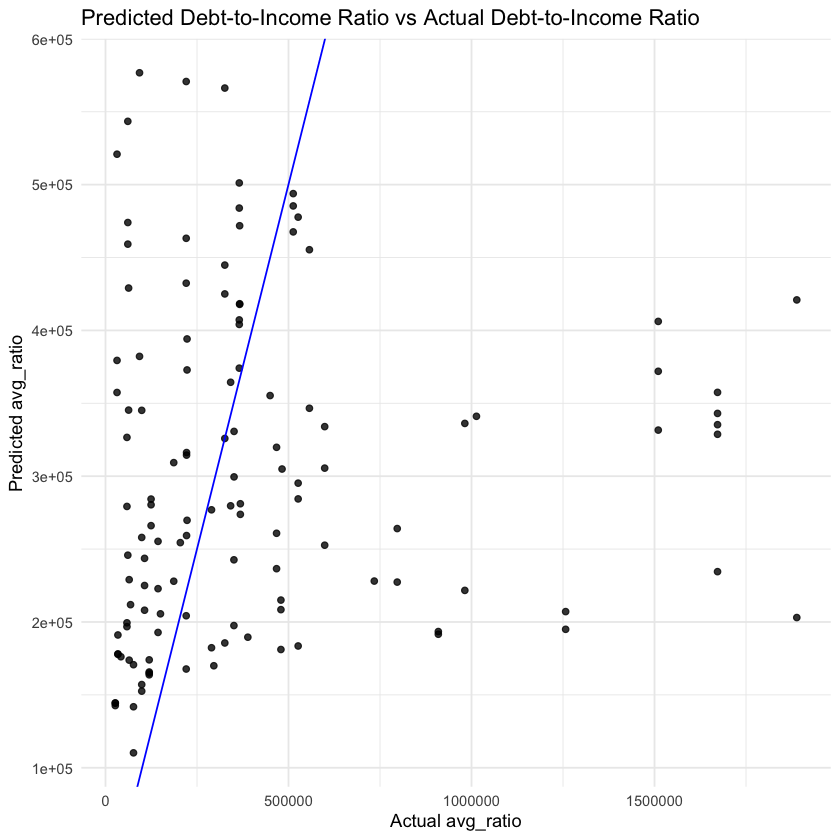

In [53]:
testData$predicted_ratio <- predicted_ratio

ggplot(testData, aes(x = avg_ratio, y = predicted_ratio)) + geom_point(alpha = 0.8) +
geom_abline(slope = 1, intercept = 0, color = "blue") +
labs(title = "Predicted Debt-to-Income Ratio vs Actual Debt-to-Income Ratio",
     x = "Actual avg_ratio",
     y = "Predicted avg_ratio") + theme_minimal()


#### Interpretation:
The model created in this analysis was moderate at predicting low- to mid-sized values but performed poorly at predicting larger values.

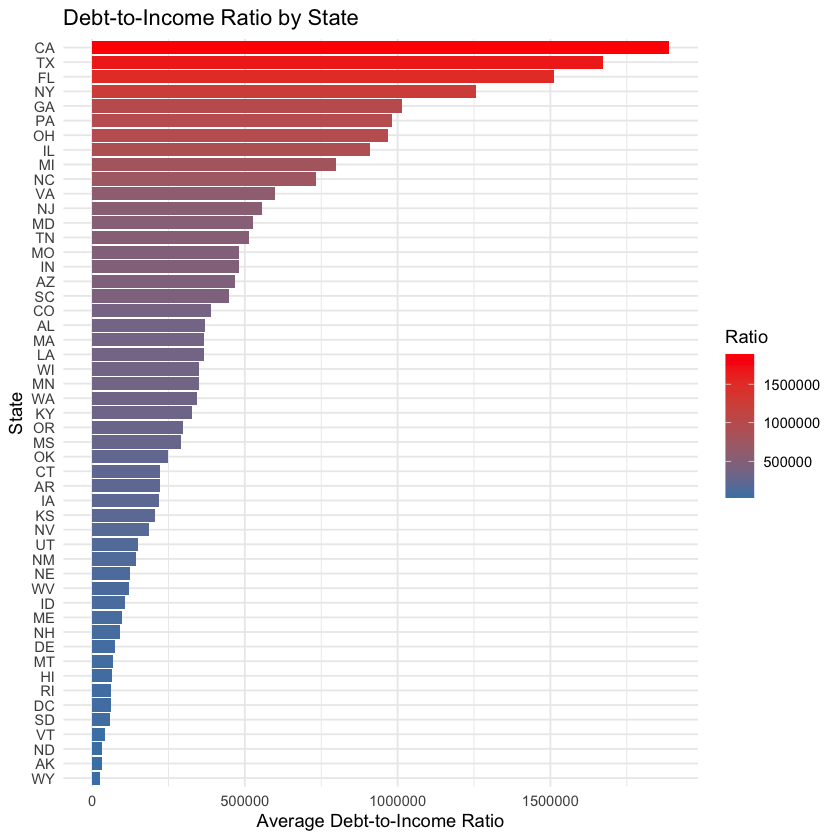

In [54]:
trainData_cv %>% # cv dataframe removed NA columns
group_by(STABBR) %>% # State Abbrivation column will function as state column
summarize(mean_ratio = mean(avg_ratio)) %>%
ggplot(aes(x = reorder(STABBR, mean_ratio), y = mean_ratio, fill = mean_ratio)) +
geom_col() +
coord_flip() +
scale_fill_gradient(low = "steel blue", high = "red") +
labs(
    title = "Debt-to-Income Ratio by State",
    x = "State",
    y = "Average Debt-to-Income Ratio",
    fill = "Ratio") + theme_minimal()

#### Interpretation:



This graphic demostates the differences in debt to income ration by state. 

#### Conclusion:

This analysis provided insight into the predictive power of tuition-related predictors and their influence on the debt-to-income ratio. The model created in this analysis was moderate at predicting low- to mid-sized values but performed poorly at predicting larger values. This model is a great exploratory segway to a more robust approach. This analysis demonstrated some of the limitations imposed by narrowing data to a scope such as the state level. This model demonstrates predictive power; with more significant predictors, it can be expanded to more accurately explain the factors contributing to differences in debt-to-income ratios across states.
